## Phase 0 — Setup

Imports and data loading. Run this before any other phase.

All segmented instances are loaded from disk — no UNet training needed here.

In [1]:
import os
import sys
import gc
import numpy as np
import torch
import matplotlib.pyplot as plt

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

sys.path.insert(0, '/home/dominik/cc-workspace/coastal')
# cecelia IO helpers come from the installed `cecelia` package
# (pip install -e <cecelia-pineapple>/python) — no sys.path / CECELIA_APP needed.

%load_ext autoreload
%autoreload 2

from coastal import (
    filter_small_cells,
    compute_3d_centroids,
    extract_cell_intensities,
    compute_cell_flow_features,
    track_physics,
    stitch_tracklets,
    score_tracking,
    optimize_tracking_cma,
    score_tracking_scalar,
    TRACKING_PARAM_BOUNDS,
)

device = (
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Device: {device}')

CH_INDICES = [0, 1, 2]   # confetti channels


Device: cuda


### Load volumes + segmentation

In [2]:
import cecelia.utils.zarr_utils as zarr_utils
import cecelia.utils.ome_xml_utils as ome_xml_utils
from cecelia.utils.dim_utils import DimUtils

uIDs     = ['xh9GFi', 'N0VlpP', 'qcN9Br', 'ENH3fS', 'uNTqPu']
base_dir = '/home/dominik/cecelia/projects/R0YiZv/ANALYSIS'

volumes = {}
pix_res = {}

for uid in uIDs:
    im_path = os.path.join(base_dir, f'0/{uid}/ccidCorrected.zarr')
    im, _   = zarr_utils.open_as_zarr(im_path, as_dask=True)
    omexml  = ome_xml_utils.parse_meta(im_path)
    dim_utils = DimUtils(omexml, use_channel_axis=True)
    dim_utils.calc_image_dimensions(im[0].shape)
    volumes[uid] = im
    pix_res[uid] = dim_utils.im_physical_sizes()

print('Loaded volumes:')
for uid in uIDs:
    T, C, Z, H, W = np.array(volumes[uid][0]).shape
    print(f'  {uid}: T={T} C={C} Z={Z} H={H} W={W} | pix_res={pix_res[uid]}')


<zarr.hierarchy.Group '/' read-only>
[61, 4, 16, 628, 625]
[625, 628, 16, 4, 61]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[61, 4, 16, 671, 632]
[632, 671, 16, 4, 61]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[61, 4, 15, 623, 624]
[624, 623, 15, 4, 61]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[61, 4, 22, 778, 930]
[930, 778, 22, 4, 61]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[61, 4, 16, 626, 627]
[627, 626, 16, 4, 61]
['X', 'Y', 'Z', 'C', 'T']
Loaded volumes:
  xh9GFi: T=61 C=4 Z=16 H=628 W=625 | pix_res={'x': 0.4830917874396135, 'y': 0.4830917874396135, 'z': 4.0}
  N0VlpP: T=61 C=4 Z=16 H=671 W=632 | pix_res={'x': 0.4830917874396135, 'y': 0.4830917874396135, 'z': 5.4285733333333335}
  qcN9Br: T=61 C=4 Z=15 H=623 W=624 | pix_res={'x': 0.4830917874396135, 'y': 0.4830917874396135, 'z': 4.0}
  ENH3fS: T=61 C=4 Z=22 H=778 W=930 | pix_res={'x': 0.4830917874396135, 'y': 0.4830917874396135, 'z': 4.0}
  uNTq

In [3]:
LABELS_DIR = '/home/dominik/Downloads/TMP/coastal_labels/'

instances_per_uid = {}
for uid in uIDs:
    path = os.path.join(LABELS_DIR, f'{uid}_instances_4d.npy')
    instances_per_uid[uid] = np.load(path, mmap_mode='r')
    print(f'Loaded {uid}: {instances_per_uid[uid].shape}')


Loaded xh9GFi: (61, 16, 628, 625)
Loaded N0VlpP: (61, 16, 671, 632)
Loaded qcN9Br: (61, 15, 623, 624)
Loaded ENH3fS: (61, 22, 778, 930)
Loaded uNTqPu: (61, 16, 626, 627)


In [4]:
from coastal import filter_small_cells

MIN_VOXELS = 200

filtered = {}
for uid, inst in instances_per_uid.items():
    f        = filter_small_cells(inst, min_voxels=MIN_VOXELS)
    removed   = [len(np.unique(inst[t])) - 1 - (len(np.unique(f[t])) - 1) for t in range(inst.shape[0])]
    remaining = [len(np.unique(f[t])) - 1 for t in range(f.shape[0])]
    print(f"{uid}:  removed mean={np.mean(removed):.1f}/frame  remaining mean={np.mean(remaining):.0f}/frame")
    filtered[uid] = f

instances_per_uid = filtered
instances_4d = next(iter(instances_per_uid.values()))   # alias for napari viewer below

# Single-volume aliases for tracking
uid_track    = uIDs[0]
vol_track    = np.asarray(volumes[uid_track][0])  # [T, C, Z, H, W]
pix_res_vol  = pix_res[uid_track]
instances_4d = instances_per_uid[uid_track]

print(f'\nTracking on: {uid_track}  instances_4d shape: {instances_4d.shape}')


## Phase 1 — Feature Extraction

Compute per-cell optical flow features and dense flow fields.
**Re-run this when switching `uid_track`.**

In [5]:
def compute_flow_for_uid(uid):
    """Compute per-cell optical flow features for a single UID.

    Returns:
        cell_flows:        {t: {cid: [u_px, v_px]}}
        dense_flow_fields: {t: [H, W, 2]}
    """
    inst    = instances_per_uid[uid]
    vol_arr = np.asarray(volumes[uid][0])                          # [T, C, Z, H, W]
    grey    = vol_arr[:, CH_INDICES].mean(axis=1).astype(np.float32)  # [T, Z, H, W]
    del vol_arr; gc.collect()

    _feats, dense_flds = compute_cell_flow_features(grey, inst, n_workers=8)
    flows = {t: {cid: f[:2] for cid, f in cells.items()}
             for t, cells in _feats.items()}
    del grey, _feats; gc.collect()

    n = sum(len(v) for v in flows.values())
    print(f'{uid}: {n} cell-frames across {len(flows)} timepoints')
    return flows, dense_flds


In [6]:
# ── Single UID (fast path — use this when iterating) ────────────────────
cell_flows, dense_flow_flds = compute_flow_for_uid(uid_track)

cell_flows_all        = {uid_track: cell_flows}
dense_flow_fields_all = {uid_track: dense_flow_flds}


xh9GFi: 47244 cell-frames across 60 timepoints


In [ ]:
# ── All UIDs (slow — only run for multi-movie optimisation) ─────────────
cell_flows_all        = {}
dense_flow_fields_all = {}

for uid in uIDs:
    cell_flows_all[uid], dense_flow_fields_all[uid] = compute_flow_for_uid(uid)

# Re-point aliases at uid_track in case they changed
cell_flows      = cell_flows_all[uid_track]
dense_flow_flds = dense_flow_fields_all[uid_track]


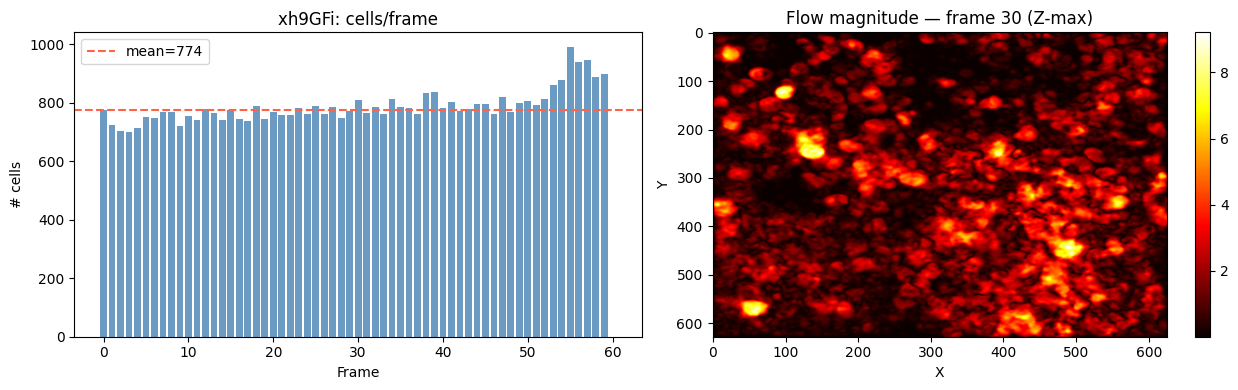

Mean cells/frame: 774.5  |  min: 0  max: 991


In [7]:
# ── Readout: cell count per frame + sample flow field ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = [len(cell_flows.get(t, {})) for t in range(instances_4d.shape[0])]
axes[0].bar(range(len(counts)), counts, color='steelblue', alpha=0.8)
axes[0].set(xlabel='Frame', ylabel='# cells', title=f'{uid_track}: cells/frame')
axes[0].axhline(np.mean(counts), color='tomato', ls='--', label=f'mean={np.mean(counts):.0f}')
axes[0].legend()

t_sample = instances_4d.shape[0] // 2
flow_f   = dense_flow_flds.get(t_sample)
if flow_f is not None:
    mag = np.sqrt((flow_f ** 2).sum(axis=2))
    im  = axes[1].imshow(mag.max(axis=0) if mag.ndim == 3 else mag,
                         cmap='hot', aspect='auto')
    plt.colorbar(im, ax=axes[1])
    axes[1].set(title=f'Flow magnitude — frame {t_sample} (Z-max)', xlabel='X', ylabel='Y')

plt.tight_layout()
plt.show()
print(f'Mean cells/frame: {np.mean(counts):.1f}  |  min: {min(counts)}  max: {max(counts)}')


## Phase 3 — Baseline Tracker

Run `track_physics` with default parameters (Kalman + flow-warp, no ABM forces).
This reproduces the best prior result (continuity≈0.729, switch_rate≈0.201).

**Target:** beat both baselines simultaneously:
- continuity ≥ 0.836 (no-emb Kalman)
- switch_rate ≤ 0.201 (Kalman + flow, best prior)

In [10]:
baseline_params = dict(
    chi2_gate=4.6,
    process_noise=1.0,
    obs_noise=9.0,
    w_flow=0.3,
    w_collective=0.0,
    w_persistence=0.0,
    w_exclusion=0.0,
    exclusion_radius_um=12.0,
    w_breadcrumb=0.0,
    breadcrumb_decay=0.9,
    cost_appear=100.0,    # large → degenerate to greedy (birth always wins)
    cost_disappear=100.0, # large → degenerate to greedy (death always wins)
    max_gap=1,
    momentum_decay=0.8,
    min_cell_size_px=0,
    max_cost=1.5,
)

tracks_baseline = track_physics(
    instances_4d=instances_4d,
    pix_res=pix_res_vol,
    cell_flows=cell_flows,
    dense_flow_fields=dense_flow_flds,
    **baseline_params,
)


track_physics: 6345 tracks over 61 frames


Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
--- Track length distribution (6345 tracks, 61 frames) ---
  min=1  p25=2  median=5  p75=10  max=54  mean=7.6
  full-length (61 frames): 0 tracks  (0%)

--- Frame-to-frame continuity (track fragmentation) ---
  mean=0.725  min=0.684  max=0.786
  Fraction of active tracks that survive each consecutive frame pair.
  1.0 = no breaks, ~0.8 = 20% of tracks re-initialise each frame.

--- Color-switch rate (within-segment identity) ---
  rate=0.2012  (7554 switches / 37540 transitions across 4685 tracks)
  mean correct-segment length: 4.0 frames  (longer = better; 1/switch_rate ≈ 5.0)

--- Switch breakdown (what causes identity errors?) ---
  within consecutive frames: 4550  (60%)  ← wrong assignment
  at a gap (non-consecutive): 3004  (40%)  ← stitching/re-init failure
  → if within-run dominates: improve per-frame cost matrix
  → if at-gap dominates: improve stitch_tracklets or gap-closing LAP

--- Fragmentation 

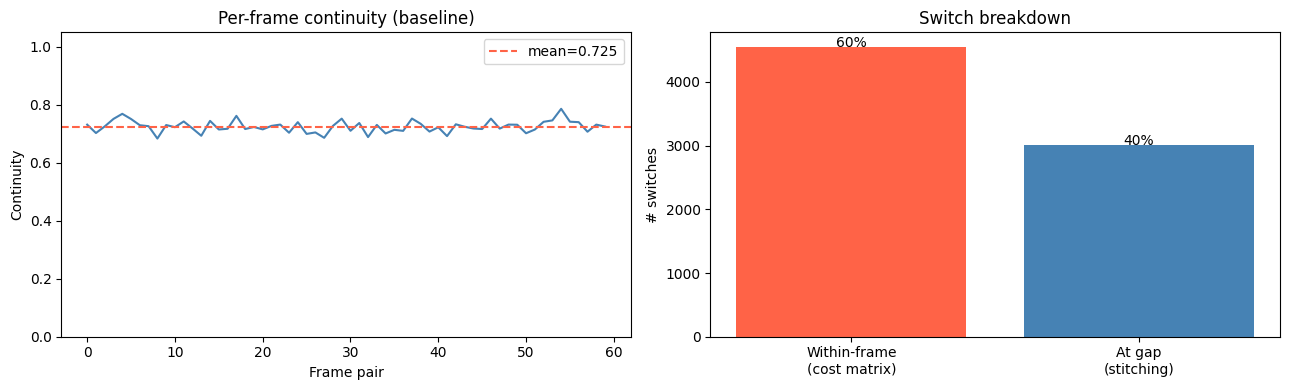

In [12]:
# ── Readout: full score + per-frame continuity + switch breakdown ───────
sc_baseline = score_tracking(
    tracks_baseline, instances_4d, vol_track,
    ch_indices=CH_INDICES, pix_res=pix_res_vol, verbose=True,
)

# Summary table
print('\n' + '='*55)
print(f'{"Metric":<30} {"Baseline":>10}')
print('-'*55)
print(f'{"continuity (mean)":<30} {sc_baseline["continuity"]["mean"]:>10.3f}')
print(f'{"switch_rate":<30} {sc_baseline["color_switch_rate"]:>10.3f}')
print(f'{"mean_segment_length":<30} {sc_baseline["mean_segment_length"]:>10.2f}')
print(f'{"n_tracks":<30} {sc_baseline["track_lengths"]["n_total"]:>10d}')
print(f'{"frac_fragmented_cells":<30} {sc_baseline["fragmentation"]["frac_fragmented"]:>10.3f}')
print('='*55)

# Per-frame continuity
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cont = sc_baseline['continuity']['per_frame']
axes[0].plot(cont, color='steelblue', lw=1.5)
axes[0].axhline(np.mean(cont), color='tomato', ls='--', label=f'mean={np.mean(cont):.3f}')
axes[0].set(xlabel='Frame pair', ylabel='Continuity', title='Per-frame continuity (baseline)',
           ylim=(0, 1.05))
axes[0].legend()

# Switch breakdown bar
sb = sc_baseline['switch_breakdown']
axes[1].bar(['Within-frame\n(cost matrix)', 'At gap\n(stitching)'],
           [sb['within_run'], sb['at_gap']], color=['tomato', 'steelblue'])
axes[1].set(title='Switch breakdown', ylabel='# switches')
for i, v in enumerate([sb['within_run'], sb['at_gap']]):
    axes[1].text(i, v + 0.5, f'{100*v/max(sb["total"],1):.0f}%', ha='center')
plt.tight_layout()
plt.show()


---
## Diagnostic — Population-Partitioned Tracking

**Hypothesis:** tracking ~270 cells per confetti population independently gives higher
continuity than tracking 800 cells together, because inter-population crossings can no
longer cause identity switches.

Two outputs:
1. **Continuity per population vs full baseline** — if population continuity is
   substantially higher, crowding is the bottleneck and partitioned GT will be reliable.
2. **Encounter statistics** — how often cells from different populations come within
   ~8 µm (crowding zone), which sets the number of hard-case training examples.

Note: switch_rate is 0 by definition for single-population tracking and is not reported.

Computing centroids and cell intensities...

=== Population sizes (cells/frame) ===
  Total     mean=790  min=700  max=991
  Red       mean=328  min=239  max=500  (41.5% of total)
  Green     mean=215  min=190  max=243  (27.2% of total)
  Blue      mean=247  min=218  max=286  (31.3% of total)

Tracking population Red (~327 cells/frame)...
track_physics: 4408 tracks over 61 frames
  → 4408 tracks

Tracking population Green (~214 cells/frame)...
track_physics: 2840 tracks over 61 frames
  → 2840 tracks

Tracking population Blue (~247 cells/frame)...
track_physics: 2973 tracks over 61 frames
  → 2973 tracks
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)

Method                      continuity   mean_seg_len   n_tracks
-----------------------------------------------------------------
Full (all 800 cells

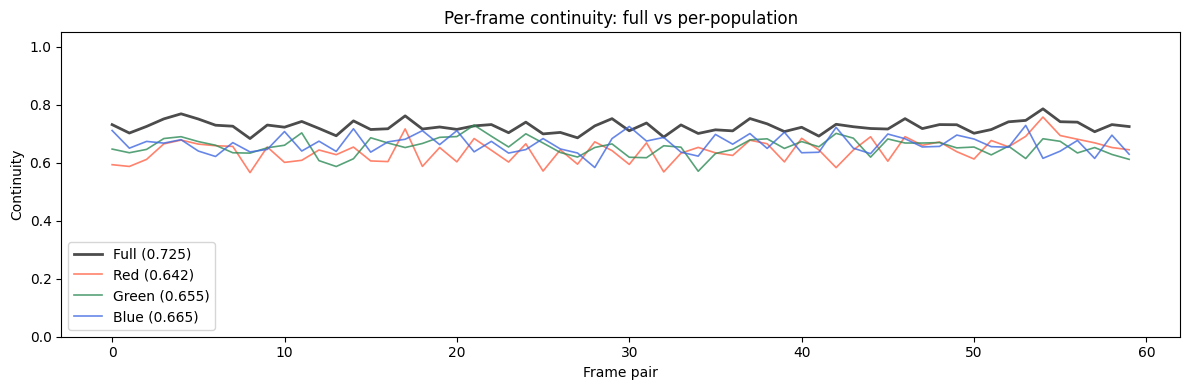


=== Inter-population encounter analysis (XY radius < 8.0 µm) ===
  Frames with ≥1 cross-population pair within 8.0µm: 61/61 (100%)
  Mean cross-population pairs within radius per frame: 402.7  (max=493)
  Min inter-population XY distance across all frames:
    mean=0.39µm  p5=0.10µm  p25=0.22µm  min=0.09µm

=== VERDICT ===
  Population continuity improvement: -0.071
  Encounter coverage: 100% of frames have cross-population pairs
  Total cross-population pairs per movie: 24563

  → NO-GO: population-specific tracking is nearly as fragmented as full tracking.
            Crowding at 270 cells is still too dense; approach won't yield clean GT.
  Center 1: 2 frames, cumulative mag: min=0.000000, max=28.830318
  Center 2: 2 frames, cumulative mag: min=0.000000, max=0.000000
  Center 1: 2 frames, cumulative mag: min=0.000000, max=23.670752
  Center 2: 2 frames, cumulative mag: min=0.000000, max=0.000000
  Center 0: 1 frames, cumulative mag: min=0.000000, max=41.069027
  Center 2: 2 frames,

In [13]:
ENCOUNTER_RADIUS_UM = 8.0   # ~2 cell diameters in XY

# ── 1. Centroids and confetti intensities ─────────────────────────────────
print("Computing centroids and cell intensities...")
all_centroids   = compute_3d_centroids(instances_4d)        # {t: {cid: [z,y,x] px}}
all_intensities = extract_cell_intensities(                 # {t: {cid: [R,G,B]}}
    instances_4d, vol_track, CH_INDICES
)
scale = np.array([pix_res_vol['z'], pix_res_vol['y'], pix_res_vol['x']], dtype=np.float32)

# ── 2. Dominant confetti color per cell ───────────────────────────────────
dominant = {}   # dominant[t][cid] = 0/1/2
for t, cells in all_intensities.items():
    dominant[t] = {cid: int(np.argmax(iv)) for cid, iv in cells.items()}

# ── 3. Per-population centroid dicts ─────────────────────────────────────
COLOR_NAMES = ['Red', 'Green', 'Blue']
pop_cents = {}
for c in range(3):
    pop_cents[c] = {
        t: {cid: pos for cid, pos in cells.items()
            if dominant.get(t, {}).get(cid, -1) == c}
        for t, cells in all_centroids.items()
    }

# ── 4. Population sizes ───────────────────────────────────────────────────
T = instances_4d.shape[0]
total_per_frame = np.array([len(all_centroids.get(t, {})) for t in range(T)])
print(f"\n=== Population sizes (cells/frame) ===")
print(f"  {'Total':<8}  mean={total_per_frame.mean():.0f}  "
      f"min={total_per_frame.min()}  max={total_per_frame.max()}")
for c in range(3):
    cnt = np.array([len(pop_cents[c].get(t, {})) for t in range(T)])
    print(f"  {COLOR_NAMES[c]:<8}  mean={cnt.mean():.0f}  "
          f"min={cnt.min()}  max={cnt.max()}  "
          f"({cnt.mean()/total_per_frame.mean()*100:.1f}% of total)")

# ── 5. Track each population with same baseline params ───────────────────
pop_tracks = {}
for c in range(3):
    print(f"\nTracking population {COLOR_NAMES[c]} (~{int(np.mean([len(pop_cents[c].get(t,{})) for t in range(T)]))} cells/frame)...")
    pop_tracks[c] = track_physics(
        instances_4d      = instances_4d,
        pix_res           = pix_res_vol,
        cell_flows        = cell_flows,
        dense_flow_fields = dense_flow_flds,
        _centroids        = pop_cents[c],
        **baseline_params,
    )
    print(f"  → {len(pop_tracks[c])} tracks")

# ── 6. Score continuity per population ───────────────────────────────────
pop_sc = {}
for c in range(3):
    pop_sc[c] = score_tracking(
        pop_tracks[c], instances_4d, vol_track,
        ch_indices = CH_INDICES,
        pix_res    = pix_res_vol,
        _centroids = pop_cents[c],
        verbose    = False,
    )

# ── 7. Comparison table ───────────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"{'Method':<25} {'continuity':>12} {'mean_seg_len':>14} {'n_tracks':>10}")
print("-" * 65)

sc_b = sc_baseline
print(f"{'Full (all 800 cells)':<25} {sc_b['continuity']['mean']:>12.3f} "
      f"{sc_b['mean_segment_length']:>14.1f} {sc_b['track_lengths']['n_total']:>10}")

pop_cont = []
for c in range(3):
    sc_c = pop_sc[c]
    cont = sc_c['continuity']['mean']
    pop_cont.append(cont)
    print(f"{'  Pop ' + COLOR_NAMES[c] + ' only':<25} {cont:>12.3f} "
          f"{sc_c['mean_segment_length']:>14.1f} {sc_c['track_lengths']['n_total']:>10}")

mean_pop_cont = np.mean(pop_cont)
delta = mean_pop_cont - sc_b['continuity']['mean']
print("-" * 65)
print(f"{'  Population mean':<25} {mean_pop_cont:>12.3f}")
print(f"{'  Delta vs baseline':<25} {delta:>+12.3f}", end="  ")
if delta > 0.08:
    print("← STRONG: crowding is the bottleneck; population GT is reliable")
elif delta > 0.03:
    print("← MODERATE: partitioning helps somewhat")
else:
    print("← WEAK: 270-cell crowding is nearly as bad as 800-cell")
print("=" * 65)

# ── 8. Per-frame continuity plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sc_b['continuity']['per_frame'], label=f'Full ({sc_b["continuity"]["mean"]:.3f})',
        color='black', lw=2, alpha=0.7)
colors_plt = ['tomato', 'seagreen', 'royalblue']
for c in range(3):
    cf = pop_sc[c]['continuity']['per_frame']
    ax.plot(cf, label=f'{COLOR_NAMES[c]} ({np.mean(cf):.3f})',
            color=colors_plt[c], lw=1.2, alpha=0.8)
ax.set(xlabel='Frame pair', ylabel='Continuity',
       title='Per-frame continuity: full vs per-population', ylim=(0, 1.05))
ax.legend()
plt.tight_layout()
plt.show()

# ── 9. Encounter analysis (XY only — crossings are 2D) ───────────────────
print(f"\n=== Inter-population encounter analysis (XY radius < {ENCOUNTER_RADIUS_UM} µm) ===")

encounter_pairs_per_frame = np.zeros(T, dtype=int)
min_xy_dist_per_frame     = np.full(T, np.inf)

for t in range(T):
    for cA, cB in [(0, 1), (0, 2), (1, 2)]:
        pts_A_px = np.array(list(pop_cents[cA].get(t, {}).values()), dtype=np.float32)
        pts_B_px = np.array(list(pop_cents[cB].get(t, {}).values()), dtype=np.float32)
        if len(pts_A_px) == 0 or len(pts_B_px) == 0:
            continue
        # XY only (µm)
        yx_A = pts_A_px[:, 1:] * scale[1:]   # [M, 2]
        yx_B = pts_B_px[:, 1:] * scale[1:]   # [N, 2]
        diff  = yx_A[:, None, :] - yx_B[None, :, :]  # [M, N, 2]
        dists = np.sqrt((diff ** 2).sum(-1))           # [M, N]
        encounter_pairs_per_frame[t] += int((dists < ENCOUNTER_RADIUS_UM).sum())
        min_xy_dist_per_frame[t] = min(min_xy_dist_per_frame[t], float(dists.min()))

finite_min = min_xy_dist_per_frame[np.isfinite(min_xy_dist_per_frame)]
frames_with_enc = int((encounter_pairs_per_frame > 0).sum())

print(f"  Frames with ≥1 cross-population pair within {ENCOUNTER_RADIUS_UM}µm: "
      f"{frames_with_enc}/{T} ({100*frames_with_enc/T:.0f}%)")
print(f"  Mean cross-population pairs within radius per frame: "
      f"{encounter_pairs_per_frame.mean():.1f}  "
      f"(max={encounter_pairs_per_frame.max()})")
print(f"  Min inter-population XY distance across all frames:")
print(f"    mean={finite_min.mean():.2f}µm  "
      f"p5={np.percentile(finite_min, 5):.2f}µm  "
      f"p25={np.percentile(finite_min, 25):.2f}µm  "
      f"min={finite_min.min():.2f}µm")

# ── 10. Summary verdict ───────────────────────────────────────────────────
print("\n=== VERDICT ===")
print(f"  Population continuity improvement: {delta:+.3f}")
print(f"  Encounter coverage: {100*frames_with_enc/T:.0f}% of frames have cross-population pairs")
print(f"  Total cross-population pairs per movie: {encounter_pairs_per_frame.sum()}")
if delta > 0.05 and frames_with_enc > T * 0.5:
    print("\n  → GO: partitioned GT is significantly cleaner AND encounters are common.")
    print("         Use population tracks as ground truth; train model on encounter frames.")
elif delta > 0.03:
    print("\n  → MAYBE: partitioning helps but weakly. Encounters may still provide useful GT.")
    print("            Examine encounter frames manually before committing to training.")
else:
    print("\n  → NO-GO: population-specific tracking is nearly as fragmented as full tracking.")
    print("            Crowding at 270 cells is still too dense; approach won't yield clean GT.")

---
## Phase 7 — Per-Population btrack GT

**Strategy:** Use confetti to partition coastal-segmented cells into 3 populations
(~270 each), run btrack independently on each — cross-population identity switches are
structurally impossible. Combine the resulting tracks into a **ground-truth assignment
table** for encounter frames, then train an assignment model on optical flow features.

Uses `pop_cents` + `all_centroids` already computed in the diagnostic cell above.
Cell IDs throughout are coastal cell IDs, so GT pairs map directly to `dense_flow_flds`.

**Quality criterion:** per-population continuity vs. baseline tells us how much
population partitioning helps. Even if similar, the tracks that *do* form are clean
(0% switch rate) and the GT pairs at encounter frames are the hard training cases.

  Pop Red: 19989 obs, 61 frames  (mean 328 cells/frame)
  Pop Green: 13090 obs, 61 frames  (mean 215 cells/frame)
  Pop Blue: 15088 obs, 61 frames  (mean 247 cells/frame)

=== per-population btrack on coastal instances (min_tp=5) ===
GLPK Integer Optimizer, v4.52
25028 rows, 21093 columns, 29672 non-zeros
21093 integer variables, all of which are binary
Preprocessing...
12514 rows, 21093 columns, 29672 non-zeros
21093 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 12514
Solving LP relaxation...
GLPK Simplex Optimizer, v4.52
12514 rows, 21093 columns, 29672 non-zeros
*     0: obj =   6.380584536e+03  infeas =  0.000e+00 (0)
*   500: obj =   6.126411950e+03  infeas =  0.000e+00 (0)
*   700: obj =   6.112627463e+03  infeas =  0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Integer optimization begins...
+   700: mip =     not foun

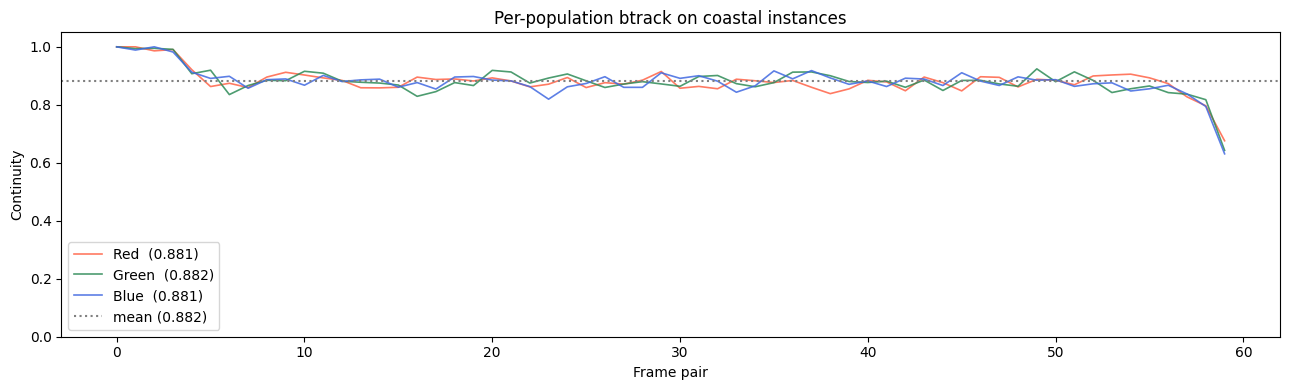

In [16]:
import btrack
import logging
import contextlib, io
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

logging.getLogger('btrack').setLevel(logging.WARNING)

from importlib.resources import files  # vendored btrack config; wheel- or editable-install-safe
BTRACK_CONFIG = os.environ.get('BTRACK_CONFIG',
    str(files('cecelia').joinpath('tasks', 'tracking', 'cell_config.json')))

# Cecelia parameter transforms (bayesian_tracking_utils.py, T-cell funParams):
CECELIA_PARAMS = dict(
    max_search_radius    = 20,
    max_lost             = 1,
    accuracy             = 8.0,      # 0.8 * 10
    prob_to_assign       = 0.8,      # → prob_not_assign = (0.1 - 1e-4) * (1 - 0.8)
    noise_initial        = 300,      # P *= 300
    noise_processing     = 100,      # G *= 100
    noise_measurements   = 100,      # R *= 100
    dist_thresh          = 10,       # hypothesis max dist (default 40)
    time_thresh          = 5,
    segmentation_miss_rate = 0.1,
    lambda_link          = 5,        # default 10
    lambda_time          = 5,
    lambda_dist          = 5,        # default 3
    lambda_branch        = 50,
    theta_time           = 5,
    theta_dist           = 5,        # default 20
    min_timepoints       = 5,
    optimizer_tm_lim     = 600_000,  # ms (10 min)
)

# ── 1. Build per-population btrack objects from coastal instances ──────────
# pop_cents[c] = {t: {cid: [z, y, x]}} in pixels — already computed above.
# btrack expects (x, y, z, t); coastal stores (z, y, x).
T_FRAMES = instances_4d.shape[0]

pop_btrack_obs = {}   # {c: {'x', 'y', 'z', 't', 'cid'}}
for c in range(3):
    xs_c, ys_c, zs_c, ts_c, cids_c = [], [], [], [], []
    for t in range(T_FRAMES):
        for cid, pos in pop_cents[c].get(t, {}).items():
            zs_c.append(float(pos[0]))
            ys_c.append(float(pos[1]))
            xs_c.append(float(pos[2]))
            ts_c.append(int(t))
            cids_c.append(int(cid))
    pop_btrack_obs[c] = {
        'x':   np.array(xs_c),
        'y':   np.array(ys_c),
        'z':   np.array(zs_c),
        't':   np.array(ts_c, dtype=np.int32),
        'cid': np.array(cids_c, dtype=np.int64),
    }
    n = len(ts_c)
    nf = len(np.unique(ts_c)) if ts_c else 0
    print(f"  Pop {COLOR_NAMES[c]}: {n} obs, {nf} frames  "
          f"(mean {n/max(nf,1):.0f} cells/frame)")

# ── 2. btrack runner ─────────────────────────────────────────────────────
def apply_cecelia_params(tracker, cfg):
    mm = tracker.motion_model
    hm = tracker.hypothesis_model
    mm.max_lost           = cfg['max_lost']
    mm.accuracy           = cfg['accuracy']
    mm.prob_not_assign    = (0.1 - 1e-4) * (1.0 - cfg['prob_to_assign'])
    mm.P                  = mm.P * cfg['noise_initial']
    mm.G                  = mm.G * cfg['noise_processing']
    mm.R                  = mm.R * cfg['noise_measurements']
    hm.lambda_link        = cfg['lambda_link']
    hm.lambda_time        = cfg['lambda_time']
    hm.lambda_dist        = cfg['lambda_dist']
    hm.lambda_branch      = cfg['lambda_branch']
    hm.theta_time         = cfg['theta_time']
    hm.theta_dist         = cfg['theta_dist']
    hm.dist_thresh        = cfg['dist_thresh']
    hm.time_thresh        = cfg['time_thresh']
    hm.segmentation_miss_rate = cfg['segmentation_miss_rate']
    tracker.max_search_radius = cfg['max_search_radius']


def run_btrack_on_population(obs, label):
    """obs: dict with keys x, y, z, t, cid (numpy arrays).
    Returns dict including 'cid_array' for GT extraction."""
    objects = btrack.utils.objects_from_dict(
        {k: obs[k] for k in ('x', 'y', 'z', 't')}
    )
    with btrack.BayesianTracker() as tracker, contextlib.redirect_stdout(io.StringIO()):
        tracker.configure(BTRACK_CONFIG)
        apply_cecelia_params(tracker, CECELIA_PARAMS)
        tracker.append(objects)
        tracker.track(step_size=100)
        tracker.optimize(options={'tm_lim': CECELIA_PARAMS['optimizer_tm_lim']})
        raw_tracks = tracker.tracks

    tracks = [tr for tr in raw_tracks if len(tr.t) >= CECELIA_PARAMS['min_timepoints']]
    t_sets = [set(tr.t) for tr in tracks]
    lens   = [len(tr.t) for tr in tracks]
    n_in   = sum(lens)
    cov    = n_in / max(len(obs['t']), 1)

    cont_per_frame = []
    for t in range(T_FRAMES - 1):
        at_t = [i for i, s in enumerate(t_sets) if t in s]
        if not at_t:
            continue
        surv = sum(1 for i in at_t if (t + 1) in t_sets[i])
        cont_per_frame.append(surv / len(at_t))

    mean_cont = float(np.mean(cont_per_frame)) if cont_per_frame else 0.0
    print(f"  {label:20s}  n_tracks={len(tracks):5d}  "
          f"mean_len={np.mean(lens):5.1f}  cov={cov:.2%}  continuity={mean_cont:.3f}")
    return {
        'tracks':         tracks,
        't_sets':         t_sets,
        'cont_per_frame': np.array(cont_per_frame),
        'continuity':     mean_cont,
        'n_tracks':       len(tracks),
        'coverage':       cov,
        'cid_array':      obs['cid'],   # local btrack ref index → coastal cell ID
    }

# ── 3. Run per population ─────────────────────────────────────────────────
print(f"\n=== per-population btrack on coastal instances "
      f"(min_tp={CECELIA_PARAMS['min_timepoints']}) ===")
res_pop_coastal = {}
for c in range(3):
    res_pop_coastal[c] = run_btrack_on_population(
        pop_btrack_obs[c], f'Pop {COLOR_NAMES[c]}'
    )

pop_mean_cont = np.mean([res_pop_coastal[c]['continuity'] for c in range(3)])
print(f"\n  Mean continuity across populations: {pop_mean_cont:.3f}")
print(f"  (Coastal Kalman best: 0.729 | no-emb Kalman: 0.836 | h5ad full btrack: 0.886)")

# ── 4. Per-frame continuity plot ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
cols_plt = ['tomato', 'seagreen', 'royalblue']
for c in range(3):
    cf = res_pop_coastal[c]['cont_per_frame']
    ax.plot(cf, color=cols_plt[c], lw=1.2, alpha=0.85,
            label=f'{COLOR_NAMES[c]}  ({res_pop_coastal[c]["continuity"]:.3f})')
ax.axhline(pop_mean_cont, color='grey', ls=':', lw=1.5,
           label=f'mean ({pop_mean_cont:.3f})')
ax.set(xlabel='Frame pair', ylabel='Continuity',
       title='Per-population btrack on coastal instances', ylim=(0, 1.05))
ax.legend()
plt.tight_layout()
plt.show()

GT: 18091 consecutive same-cell pairs (coastal cell IDs)
Encounter-zone (hard) GT pairs: 9536  (52.7% of all GT pairs)
Frames with ≥1 hard GT pair: 60/61 (98%)
Hard GT pairs/frame: mean=158.9  max=197


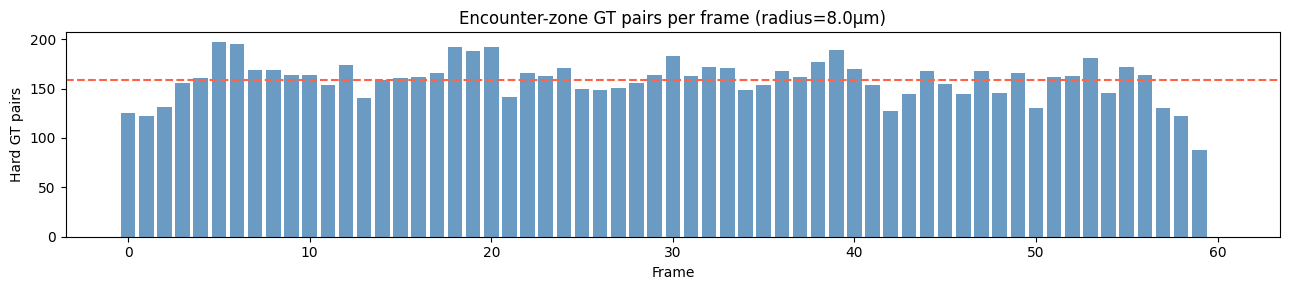


=== GT READINESS ===
  READY: 9536 hard GT pairs across 60 frames.
  Next: extract flow features per GT pair → train assignment model.


In [17]:
# ── 5. Build GT assignment table from coastal cell IDs ───────────────────
# For each population's btrack tracks, map consecutive observations back to
# coastal cell IDs using cid_array (preserved insertion order = pop_btrack_obs order).
# tr.refs[k] < 0 → btrack dummy gap-fill object; skip.

ENCOUNTER_RADIUS_UM_GT = 8.0
scale_xy = np.array([pix_res_vol['y'], pix_res_vol['x']], dtype=np.float32)

# GT assignments: (t, coastal_cid_at_t, coastal_cid_at_t1)
gt_assignments = []

for c in range(3):
    cid_arr = res_pop_coastal[c]['cid_array']   # local btrack idx → coastal cid
    for tr in res_pop_coastal[c]['tracks']:
        t_arr = list(tr.t)
        refs  = list(tr.refs)
        for k in range(len(t_arr) - 1):
            t0, t1 = t_arr[k], t_arr[k + 1]
            r0, r1 = refs[k], refs[k + 1]
            if t1 != t0 + 1:
                continue   # gap > 1 frame
            if r0 < 0 or r1 < 0:
                continue   # btrack dummy object
            gt_assignments.append((t0, int(cid_arr[r0]), int(cid_arr[r1])))

print(f"GT: {len(gt_assignments)} consecutive same-cell pairs (coastal cell IDs)")

# ── 6. Encounter-zone filter ──────────────────────────────────────────────
# For each GT pair, check whether the source cell at t has a cross-population
# neighbour within ENCOUNTER_RADIUS_UM_GT µm in XY.
# Uses pop_cents[c] (coastal positions in pixels).

# Pre-build {c: {t: array([y, x] in µm)}} for fast distance checks
pop_yx_um = {}
pop_cids_by_frame = {}
for c in range(3):
    pop_yx_um[c]       = {}
    pop_cids_by_frame[c] = {}
    for t, cell_dict in pop_cents[c].items():
        if not cell_dict:
            continue
        cids_arr = np.array(list(cell_dict.keys()), dtype=np.int64)
        pos_arr  = np.array(list(cell_dict.values()), dtype=np.float32)  # [N, 3] z,y,x px
        pop_cids_by_frame[c][t] = cids_arr
        pop_yx_um[c][t]         = pos_arr[:, 1:] * scale_xy   # [N, 2] y,x µm

hard_gt = []
for (t0, cid0, cid1) in gt_assignments:
    c_src = int(dominant[t0].get(cid0, -1))
    if c_src < 0:
        continue
    pos0 = all_centroids[t0].get(cid0)
    if pos0 is None:
        continue
    xy_src = np.array([pos0[1], pos0[2]], dtype=np.float32) * scale_xy   # µm

    has_neighbour = False
    for c_other in range(3):
        if c_other == c_src:
            continue
        yx_other = pop_yx_um[c_other].get(t0)
        if yx_other is None or len(yx_other) == 0:
            continue
        dists = np.sqrt(((yx_other - xy_src) ** 2).sum(axis=1))
        if dists.min() < ENCOUNTER_RADIUS_UM_GT:
            has_neighbour = True
            break
    if has_neighbour:
        hard_gt.append((t0, cid0, cid1))

print(f"Encounter-zone (hard) GT pairs: {len(hard_gt)}  "
      f"({100*len(hard_gt)/max(len(gt_assignments),1):.1f}% of all GT pairs)")

frame_counts = np.zeros(T_FRAMES, dtype=int)
for (t0, _, _) in hard_gt:
    frame_counts[t0] += 1

frames_with_hard = int((frame_counts > 0).sum())
print(f"Frames with ≥1 hard GT pair: {frames_with_hard}/{T_FRAMES} "
      f"({100*frames_with_hard/T_FRAMES:.0f}%)")
print(f"Hard GT pairs/frame: mean={frame_counts[frame_counts>0].mean():.1f}  "
      f"max={frame_counts.max()}")

fig, ax = plt.subplots(figsize=(13, 3))
ax.bar(range(T_FRAMES), frame_counts, color='steelblue', alpha=0.8)
ax.axhline(frame_counts[frame_counts > 0].mean(), color='tomato', ls='--')
ax.set(xlabel='Frame', ylabel='Hard GT pairs',
       title=f'Encounter-zone GT pairs per frame (radius={ENCOUNTER_RADIUS_UM_GT}µm)')
plt.tight_layout()
plt.show()

print("\n=== GT READINESS ===")
if len(hard_gt) >= 5000 and frames_with_hard >= T_FRAMES * 0.7:
    print(f"  READY: {len(hard_gt)} hard GT pairs across {frames_with_hard} frames.")
    print("  Next: extract flow features per GT pair → train assignment model.")
elif len(hard_gt) >= 1000:
    print(f"  MARGINAL: {len(hard_gt)} hard GT pairs.")
    print("  Consider training on all GT pairs, not just encounter-zone.")
else:
    print(f"  NOT ENOUGH: only {len(hard_gt)} hard GT pairs.")
    print("  Reduce ENCOUNTER_RADIUS_UM_GT or use all GT pairs.")

---
### Phase 7b — Flow-Feature Assignment Model

For each GT pair `(t, cid_src, cid_tgt)` compute a 6-dim feature using
only the dense optical flow field — no confetti, no learned embeddings:

| Feature | Description |
|---------|-------------|
| `dy`, `dx` | Actual displacement (src→tgt) in µm |
| `fv`, `fu` | Flow prediction at src: `dense_flow_flds[t][y_src, x_src]` in µm |
| `dev_y`, `dev_x` | Deviation: actual − predicted (µm) |

Negatives: cells at `t+1` within a candidate radius of `cid_src` that are NOT `cid_tgt`.
Geometrically plausible but wrong assignments — the hardest negatives.

**Signal check:** AUC > 0.6 → flow features discriminate correct from wrong assignments;
use as extra cost term in the LAP solver to replace the geometric `w_flow` heuristic.

Dataset: 9536 positives, 67467 negatives  (ratio 7.1:1)
Features: [dy, dx, fv, fu, dev_y, dev_x]  (all in µm)

5-fold CV AUC: 0.508 ± 0.005

Coefficients:
  fv       +0.021
  dev_y    -0.019
  dy       -0.015
  fu       -0.006
  dev_x    +0.004
  dx       +0.003


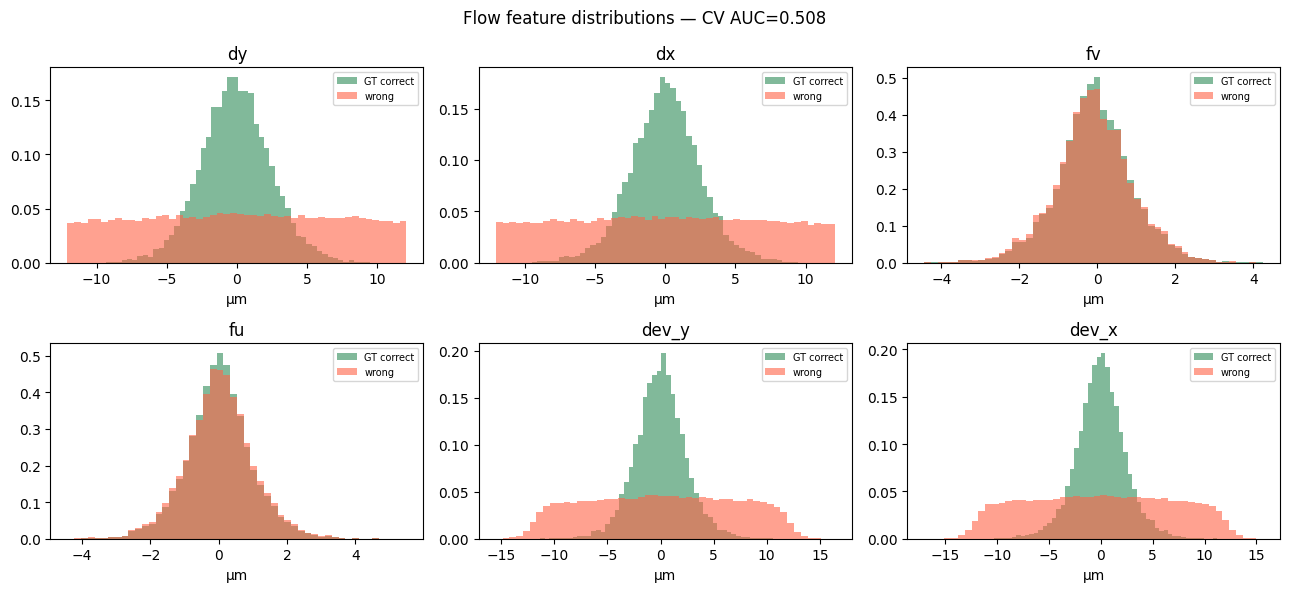


WEAK signal (AUC=0.508): flow features do not discriminate assignments.
  Check if dense_flow_flds are at the right scale / not all-zero.


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Build flat centroid lookup from all_centroids ──────────────────────
# {t: {cid: np.array([z, y, x] in px)}}  — already available
pix_y = pix_res_vol['y']
pix_x = pix_res_vol['x']

NEG_RADIUS_PX = 25   # candidate search radius for negative mining (pixels)

def pair_features(t0, cid_src, cid_tgt, flow_flds):
    """6-dim flow feature for one candidate assignment (src at t0 → tgt at t0+1)."""
    pos_src = all_centroids[t0].get(cid_src)
    pos_tgt = all_centroids.get(t0 + 1, {}).get(cid_tgt)
    if pos_src is None or pos_tgt is None:
        return None
    y_src, x_src = pos_src[1], pos_src[2]
    y_tgt, x_tgt = pos_tgt[1], pos_tgt[2]

    dy_um = (y_tgt - y_src) * pix_y
    dx_um = (x_tgt - x_src) * pix_x

    flow = flow_flds.get(t0)
    if flow is None:
        fv_um = fu_um = 0.0
    else:
        yi, xi = int(round(y_src)), int(round(x_src))
        yi = np.clip(yi, 0, flow.shape[0] - 1)
        xi = np.clip(xi, 0, flow.shape[1] - 1)
        fu_um = float(flow[yi, xi, 0]) * pix_x   # u = x-direction
        fv_um = float(flow[yi, xi, 1]) * pix_y   # v = y-direction

    return np.array([dy_um, dx_um, fv_um, fu_um,
                     dy_um - fv_um, dx_um - fu_um], dtype=np.float32)

# ── 2. Build positive + negative feature arrays ───────────────────────────
X_list, y_list = [], []

for (t0, cid_src, cid_tgt) in hard_gt:
    feat_pos = pair_features(t0, cid_src, cid_tgt, dense_flow_flds)
    if feat_pos is None:
        continue
    X_list.append(feat_pos)
    y_list.append(1)

    # Negative mining: other cells at t+1 near cid_src (not cid_tgt)
    pos_src = all_centroids[t0].get(cid_src)
    if pos_src is None:
        continue
    ys, xs = pos_src[1], pos_src[2]
    cells_t1 = all_centroids.get(t0 + 1, {})
    for cid_neg, pos_neg in cells_t1.items():
        if cid_neg == cid_tgt:
            continue
        dy_px = abs(pos_neg[1] - ys)
        dx_px = abs(pos_neg[2] - xs)
        if dy_px > NEG_RADIUS_PX or dx_px > NEG_RADIUS_PX:
            continue
        feat_neg = pair_features(t0, cid_src, cid_neg, dense_flow_flds)
        if feat_neg is None:
            continue
        X_list.append(feat_neg)
        y_list.append(0)

X = np.stack(X_list)
y = np.array(y_list)

n_pos = y.sum()
n_neg = (y == 0).sum()
print(f"Dataset: {n_pos} positives, {n_neg} negatives  "
      f"(ratio {n_neg/max(n_pos,1):.1f}:1)")
print(f"Features: [dy, dx, fv, fu, dev_y, dev_x]  (all in µm)")

# ── 3. Train logistic regression ─────────────────────────────────────────
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
aucs = cross_val_score(clf, X_sc, y, cv=5, scoring='roc_auc')
print(f"\n5-fold CV AUC: {aucs.mean():.3f} ± {aucs.std():.3f}")

clf.fit(X_sc, y)
feat_names = ['dy', 'dx', 'fv', 'fu', 'dev_y', 'dev_x']
print("\nCoefficients:")
for name, coef in sorted(zip(feat_names, clf.coef_[0]), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:8s} {coef:+.3f}")

# ── 4. Feature distributions: positive vs negative ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
axes = axes.flatten()
for i, name in enumerate(feat_names):
    ax = axes[i]
    ax.hist(X[y==1, i], bins=50, alpha=0.6, color='seagreen', label='GT correct', density=True)
    ax.hist(X[y==0, i], bins=50, alpha=0.6, color='tomato',   label='wrong',      density=True)
    ax.set(title=name, xlabel='µm')
    ax.legend(fontsize=7)
plt.suptitle(f'Flow feature distributions — CV AUC={aucs.mean():.3f}')
plt.tight_layout()
plt.show()

# ── 5. Verdict ────────────────────────────────────────────────────────────
auc = aucs.mean()
if auc >= 0.75:
    print(f"\nSTRONG signal (AUC={auc:.3f}): use as assignment cost in LAP solver.")
elif auc >= 0.6:
    print(f"\nMODERATE signal (AUC={auc:.3f}): worth integrating, likely marginal gain.")
else:
    print(f"\nWEAK signal (AUC={auc:.3f}): flow features do not discriminate assignments.")
    print("  Check if dense_flow_flds are at the right scale / not all-zero.")


---
## Phase 7c — Full-population btrack + Failure Analysis

Run btrack on all ~800 coastal instances at once (no confetti split).

Goals:
1. Establish the full-population btrack baseline (continuity + switch_rate)
2. Identify where it fails vs per-population tracking (0 within-pop switches by construction)
3. Map the failure mode spatially and temporally to inform the adaptation design


Full-pop: 48167 obs, 61 frames, mean 790 cells/frame
Running btrack on full population (GLPK optimizer ≤10 min) …
GLPK Integer Optimizer, v4.52
48828 rows, 43809 columns, 63204 non-zeros
43809 integer variables, all of which are binary
Preprocessing...
24414 rows, 43809 columns, 63204 non-zeros
43809 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 24414
Solving LP relaxation...
GLPK Simplex Optimizer, v4.52
24414 rows, 43809 columns, 63204 non-zeros
*     0: obj =   1.236824393e+04  infeas =  0.000e+00 (0)
*   500: obj =   1.187884769e+04  infeas =  0.000e+00 (0)
*  1000: obj =   1.165040947e+04  infeas =  0.000e+00 (0)
*  1500: obj =   1.151996023e+04  infeas =  0.000e+00 (0)
*  2000: obj =   1.146098864e+04  infeas =  0.000e+00 (0)
*  2328: obj =   1.145195003e+04  infeas =  0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Inte

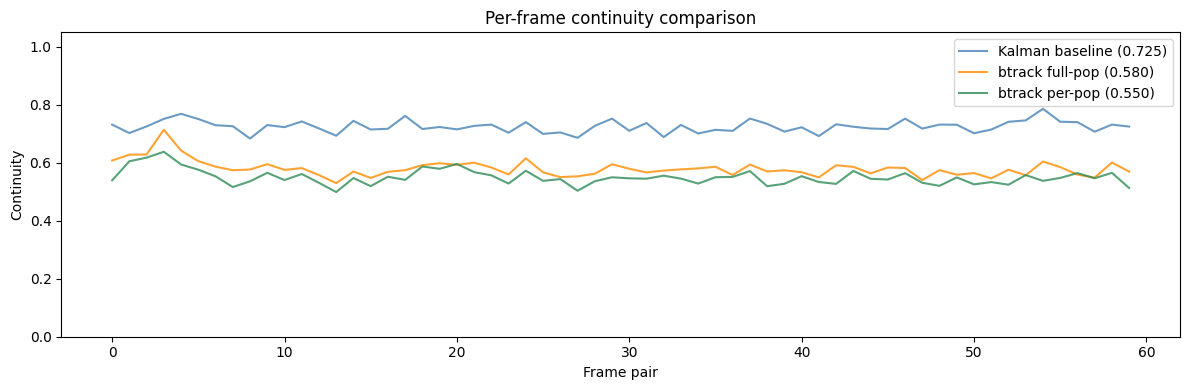

In [25]:
# ── Helper: btrack Tracklets → {tid: {t: pos_um}} for score_tracking ────
scale_um = np.array([pix_res_vol['z'], pix_res_vol['y'], pix_res_vol['x']], dtype=np.float32)

def btrack_to_tracks_um(tracklets, cid_array, centroids, scale):
    """Convert btrack Tracklet objects to {track_id: {t: pos_um [z,y,x]}}."""
    out = {}
    for i, tr in enumerate(tracklets):
        td = {}
        for k in range(len(tr.t)):
            r = tr.refs[k]
            if r < 0:           # dummy gap-fill
                continue
            t = tr.t[k]
            cid = int(cid_array[r])
            pos_px = centroids.get(t, {}).get(cid)
            if pos_px is None:
                continue
            td[t] = pos_px * scale
        if len(td) >= 2:
            out[i] = td
    return out

# ── 1. Build full-population observation set from all_centroids ──────────
all_xs_f, all_ys_f, all_zs_f, all_ts_f, all_cids_f = [], [], [], [], []
for t in sorted(all_centroids.keys()):
    for cid, pos in all_centroids[t].items():
        all_zs_f.append(float(pos[0]))
        all_ys_f.append(float(pos[1]))
        all_xs_f.append(float(pos[2]))
        all_ts_f.append(int(t))
        all_cids_f.append(int(cid))

full_obs_all = {
    'x':   np.array(all_xs_f),
    'y':   np.array(all_ys_f),
    'z':   np.array(all_zs_f),
    't':   np.array(all_ts_f,   dtype=np.int32),
    'cid': np.array(all_cids_f, dtype=np.int64),
}
n_obs_f = len(all_ts_f)
n_frs   = len(set(all_ts_f))
print(f"Full-pop: {n_obs_f} obs, {n_frs} frames, mean {n_obs_f/n_frs:.0f} cells/frame")
print("Running btrack on full population (GLPK optimizer ≤10 min) …")

# ── 2. Run btrack ─────────────────────────────────────────────────────────
objects_all = btrack.utils.objects_from_dict(
    {k: full_obs_all[k] for k in ('x', 'y', 'z', 't')}
)
with btrack.BayesianTracker() as tracker, contextlib.redirect_stdout(io.StringIO()):
    tracker.configure(BTRACK_CONFIG)
    apply_cecelia_params(tracker, CECELIA_PARAMS)
    tracker.append(objects_all)
    tracker.track(step_size=100)
    tracker.optimize(options={'tm_lim': CECELIA_PARAMS['optimizer_tm_lim']})
    raw_tracks_full_pop = tracker.tracks

tracks_full_pop_long = [
    tr for tr in raw_tracks_full_pop
    if len(tr.t) >= CECELIA_PARAMS['min_timepoints']
]
print(f"Full btrack: {len(raw_tracks_full_pop)} raw → "
      f"{len(tracks_full_pop_long)} tracks (≥{CECELIA_PARAMS['min_timepoints']} frames)")

# ── 3. Convert to score_tracking format ──────────────────────────────────
full_cid_arr = full_obs_all['cid']
tracks_btrack_full = btrack_to_tracks_um(
    tracks_full_pop_long, full_cid_arr, all_centroids, scale_um
)

# ── 4. Per-population combined tracks (0 within-pop switches by construction)
tracks_per_pop = {}
for c in range(3):
    pop_tr = btrack_to_tracks_um(
        res_pop_coastal[c]['tracks'],
        res_pop_coastal[c]['cid_array'],
        all_centroids, scale_um,
    )
    for tid, td in pop_tr.items():
        tracks_per_pop[c * 10000 + tid] = td

print(f"Per-pop combined: {len(tracks_per_pop)} tracks")

# ── 5. Score both ────────────────────────────────────────────────────────
print("\nScoring …")
sc_btrack_full = score_tracking(
    tracks_btrack_full, instances_4d, vol_track,
    ch_indices=CH_INDICES, pix_res=pix_res_vol, verbose=False,
)
sc_per_pop = score_tracking(
    tracks_per_pop, instances_4d, vol_track,
    ch_indices=CH_INDICES, pix_res=pix_res_vol, verbose=False,
)

# ── 6. Comparison table ───────────────────────────────────────────────────
import pandas as pd

def fmt_row(label, sc):
    sb = sc['switch_breakdown']
    tot = max(sb['within_run'] + sb['at_gap'], 1e-9)
    return {
        'Method':       label,
        'continuity':   sc['continuity']['mean'],
        'switch_rate':  sc['color_switch_rate'],
        'within_run%':  sb['within_run'] / tot * 100,
        'gap%':         sb['at_gap']     / tot * 100,
        'n_tracks':     sc['track_lengths']['n_total'],
    }

rows = [
    fmt_row('Kalman + flow-warp (baseline)', sc_baseline),
    fmt_row('btrack full-pop',              sc_btrack_full),
    fmt_row('btrack per-pop combined',      sc_per_pop),
]
df = pd.DataFrame(rows).set_index('Method')
print("\n" + df.to_string(float_format='{:.3f}'.format))

# Per-frame continuity overlay
fig, ax = plt.subplots(figsize=(12, 4))
for label, sc, col in [
    ('Kalman baseline', sc_baseline,    'steelblue'),
    ('btrack full-pop', sc_btrack_full, 'darkorange'),
    ('btrack per-pop',  sc_per_pop,     'seagreen'),
]:
    c = sc['continuity']['per_frame']
    ax.plot(c, label=f'{label} ({np.mean(c):.3f})', color=col, alpha=0.8)
ax.set(xlabel='Frame pair', ylabel='Continuity',
       title='Per-frame continuity comparison', ylim=(0, 1.05))
ax.legend()
plt.tight_layout()
plt.show()


Cross-population transitions: 4015 / 21421 = 18.7%
(compare: score_tracking switch_rate=0.285)

Population confusion matrix (row=source pop → col=target pop):
           Red tgt  Green tgt  Blue tgt
Red src          0        758       708
Green src      793          0       528
Blue src       717        511         0

Worst 5 frame pairs:
  t=15→16: 81/338 (24.0%)
  t=29→30: 86/363 (23.7%)
  t=14→15: 78/339 (23.0%)
  t=7→8: 82/363 (22.6%)
  t=23→24: 78/351 (22.2%)


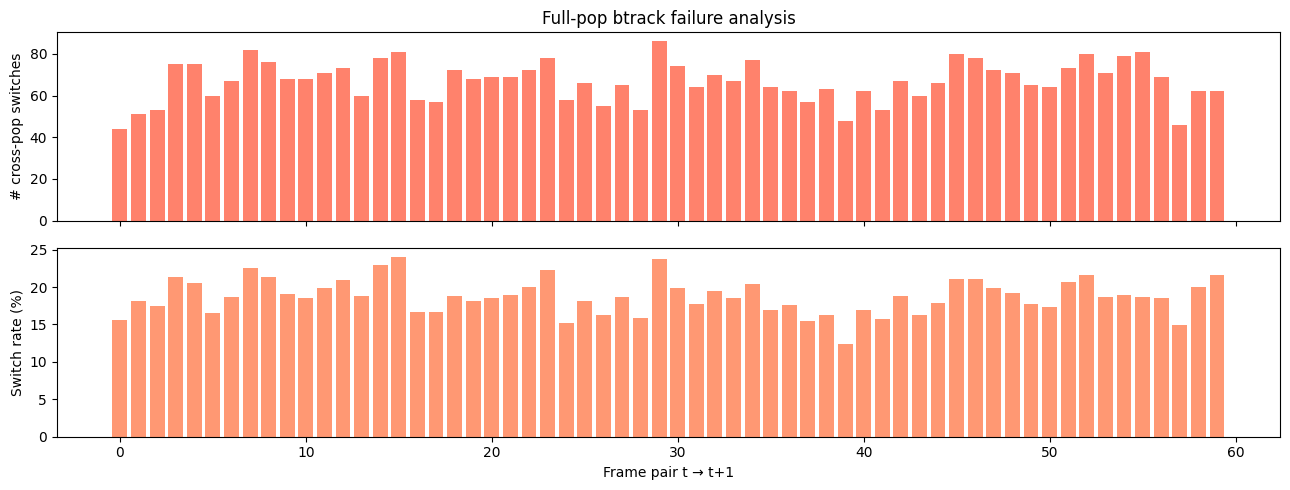

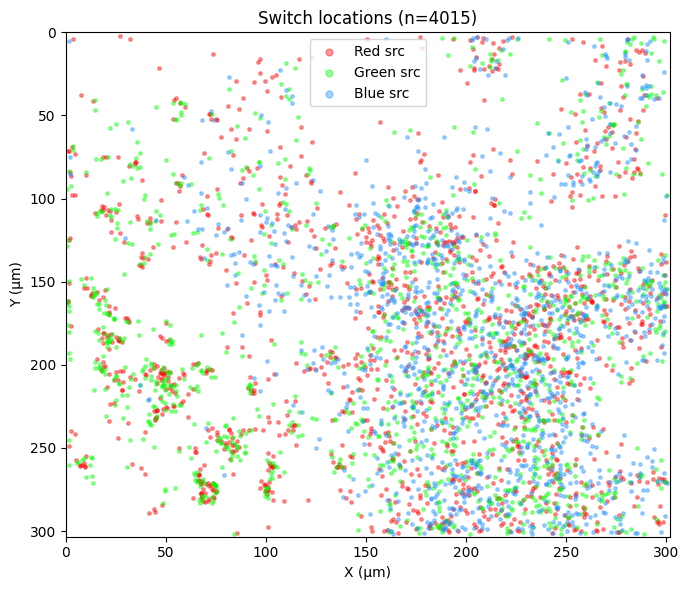


Median NN distance at switch sites: 4.0 µm
Median NN distance overall:          4.0 µm


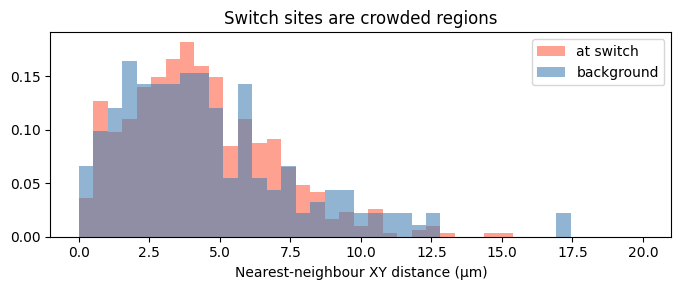

In [26]:
# ── Failure analysis: where does full-pop btrack go wrong? ────────────────
# Build cid → population lookup from pop_cents
cid_to_pop = {}
for c in range(3):
    for t, cells in pop_cents[c].items():
        if t not in cid_to_pop:
            cid_to_pop[t] = {}
        for cid in cells:
            cid_to_pop[t][cid] = c

COLOR_NAMES_3 = ['Red', 'Green', 'Blue']

# Walk full-pop btrack tracks; detect cross-population consecutive assignments
pop_confusion    = np.zeros((3, 3), dtype=int)   # [pop_src, pop_tgt]
switch_per_frame = np.zeros(T_FRAMES - 1, dtype=int)
total_per_frame  = np.zeros(T_FRAMES - 1, dtype=int)
switch_positions = []   # (t, y_um, x_um, pop_src, pop_tgt)

for tr in tracks_full_pop_long:
    prev_pop, prev_t = None, None
    for k in range(len(tr.t)):
        r = tr.refs[k]
        if r < 0:
            continue
        t   = tr.t[k]
        cid = int(full_cid_arr[r])
        pop = cid_to_pop.get(t, {}).get(cid, -1)
        if prev_t is not None and t == prev_t + 1 and pop >= 0 and prev_pop >= 0:
            total_per_frame[prev_t] += 1
            if pop != prev_pop:
                pop_confusion[prev_pop, pop] += 1
                switch_per_frame[prev_t] += 1
                pos = all_centroids.get(t, {}).get(cid)
                if pos is not None:
                    switch_positions.append(
                        (t, pos[1]*pix_res_vol['y'], pos[2]*pix_res_vol['x'], prev_pop, pop)
                    )
        if pop >= 0:
            prev_pop, prev_t = pop, t

n_switches = pop_confusion.sum()
n_total    = total_per_frame.sum()
print(f"Cross-population transitions: {n_switches} / {n_total} = {n_switches/max(n_total,1)*100:.1f}%")
print(f"(compare: score_tracking switch_rate={sc_btrack_full['color_switch_rate']:.3f})")
print()

# Population confusion matrix
conf_df = pd.DataFrame(
    pop_confusion,
    index  =[f'{n} src' for n in COLOR_NAMES_3],
    columns=[f'{n} tgt' for n in COLOR_NAMES_3],
)
print("Population confusion matrix (row=source pop → col=target pop):")
print(conf_df.to_string())
print()

# Worst frame pairs
sw_rate_pf = np.where(total_per_frame > 0, switch_per_frame / total_per_frame, 0.0)
worst5 = np.argsort(sw_rate_pf)[-5:][::-1]
print("Worst 5 frame pairs:")
for t in worst5:
    print(f"  t={t}→{t+1}: {switch_per_frame[t]}/{total_per_frame[t]} "
          f"({sw_rate_pf[t]*100:.1f}%)")

# ── Per-frame switch rate plot ────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
axes[0].bar(range(T_FRAMES - 1), switch_per_frame, color='tomato', alpha=0.8)
axes[0].set(ylabel='# cross-pop switches', title='Full-pop btrack failure analysis')
axes[1].bar(range(T_FRAMES - 1), sw_rate_pf * 100, color='coral', alpha=0.8)
axes[1].set(xlabel='Frame pair t → t+1', ylabel='Switch rate (%)')
plt.tight_layout()
plt.show()

# ── Spatial distribution of switches ─────────────────────────────────────
if switch_positions:
    sw_arr = np.array([(y, x, ps, pt) for t, y, x, ps, pt in switch_positions])
    fig, ax = plt.subplots(figsize=(7, 6))
    palette = ['red', 'lime', 'dodgerblue']
    # colour by source population
    for ps in range(3):
        mask = sw_arr[:, 2] == ps
        ax.scatter(sw_arr[mask, 1], sw_arr[mask, 0], s=6, alpha=0.4,
                   c=palette[ps], label=f'{COLOR_NAMES_3[ps]} src')
    ax.set(
        xlabel='X (µm)', ylabel='Y (µm)',
        title=f'Switch locations (n={len(sw_arr)})',
        xlim=(0, instances_4d.shape[3]*pix_res_vol['x']),
        ylim=(instances_4d.shape[2]*pix_res_vol['y'], 0)
    )
    ax.legend(markerscale=2)
    plt.tight_layout()
    plt.show()

# ── Nearest-neighbour distance: switch sites vs everywhere ────────────────
rng = np.random.default_rng(42)
nn_switch, nn_bg = [], []

for t, y_um, x_um, ps, pt in switch_positions[:600]:
    cells = all_centroids.get(t, {})
    if len(cells) < 2:
        continue
    poss = np.array([[v[1]*pix_res_vol['y'], v[2]*pix_res_vol['x']] for v in cells.values()])
    d = np.sort(np.sqrt(((poss - [y_um, x_um])**2).sum(axis=1)))
    nn_switch.append(d[d > 0.1][0] if (d > 0.1).any() else np.nan)

for t in rng.integers(0, T_FRAMES, 30):
    cells = all_centroids.get(int(t), {})
    cids  = list(cells.keys())
    if len(cids) < 2:
        continue
    for cid in rng.choice(cids, min(6, len(cids)), replace=False):
        pos  = cells[cid]
        poss = np.array([[v[1]*pix_res_vol['y'], v[2]*pix_res_vol['x']] for v in cells.values()])
        d    = np.sort(np.sqrt(((poss - [pos[1]*pix_res_vol['y'], pos[2]*pix_res_vol['x']])**2).sum(axis=1)))
        nn_bg.append(d[d > 0.1][0] if (d > 0.1).any() else np.nan)

nn_switch = np.array(nn_switch)
nn_bg     = np.array(nn_bg)
print(f"\nMedian NN distance at switch sites: {np.nanmedian(nn_switch):.1f} µm")
print(f"Median NN distance overall:          {np.nanmedian(nn_bg):.1f} µm")

fig, ax = plt.subplots(figsize=(7, 3))
bins = np.linspace(0, 20, 40)
ax.hist(nn_switch[~np.isnan(nn_switch)], bins=bins, alpha=0.6,
        color='tomato',   density=True, label='at switch')
ax.hist(nn_bg[~np.isnan(nn_bg)],         bins=bins, alpha=0.6,
        color='steelblue', density=True, label='background')
ax.set(xlabel='Nearest-neighbour XY distance (µm)',
       title='Switch sites are crowded regions')
ax.legend()
plt.tight_layout()
plt.show()


---
### Bug fix: gap-fill frames

The original `btrack_to_tracks_um` skips frames where `refs[k] < 0` (btrack gap-fill
dummies), leaving holes in the track dict. `score_tracking` counts each hole as a track
break, artificially crushing the measured continuity.

Fix: use btrack's Kalman-predicted position (`tr.x[k], tr.y[k], tr.z[k]`) for gap
frames — those coordinates are always populated even for dummies.


In [27]:
# ── Re-define helper with gap-fill support ────────────────────────────────
def btrack_to_tracks_um(tracklets, cid_array, centroids, scale):
    """Convert btrack Tracklets to {tid: {t: pos_um [z,y,x]}}.

    Real obs (refs>=0) → coastal centroid (authoritative).
    Gap fill (refs<0)  → btrack Kalman prediction (tr.z/y/x in pixels).
    """
    out = {}
    for i, tr in enumerate(tracklets):
        td = {}
        for k in range(len(tr.t)):
            t = int(tr.t[k])
            r = tr.refs[k]
            if r >= 0:
                cid    = int(cid_array[r])
                pos_px = centroids.get(t, {}).get(cid)
                if pos_px is not None:
                    td[t] = pos_px * scale
            else:
                # Kalman prediction: btrack stores x=col, y=row, z=slice in pixels
                td[t] = np.array([tr.z[k] * scale[0],
                                   tr.y[k] * scale[1],
                                   tr.x[k] * scale[2]], dtype=np.float32)
        if len(td) >= 2:
            out[i] = td
    return out

# ── Re-convert existing btrack results (no need to re-run GLPK) ──────────
tracks_btrack_full = btrack_to_tracks_um(
    tracks_full_pop_long, full_cid_arr, all_centroids, scale_um
)
tracks_per_pop = {}
for c in range(3):
    pop_tr = btrack_to_tracks_um(
        res_pop_coastal[c]['tracks'],
        res_pop_coastal[c]['cid_array'],
        all_centroids, scale_um,
    )
    for tid, td in pop_tr.items():
        tracks_per_pop[c * 10000 + tid] = td

# ── Re-score ──────────────────────────────────────────────────────────────
print("Re-scoring with gap-fill fix …")
sc_btrack_full = score_tracking(
    tracks_btrack_full, instances_4d, vol_track,
    ch_indices=CH_INDICES, pix_res=pix_res_vol, verbose=False,
)
sc_per_pop = score_tracking(
    tracks_per_pop, instances_4d, vol_track,
    ch_indices=CH_INDICES, pix_res=pix_res_vol, verbose=False,
)

rows = [
    fmt_row('Kalman + flow-warp (baseline)', sc_baseline),
    fmt_row('btrack full-pop (fixed)',       sc_btrack_full),
    fmt_row('btrack per-pop combined (fixed)', sc_per_pop),
]
df = pd.DataFrame(rows).set_index('Method')
print("\n" + df.to_string(float_format='{:.3f}'.format))

# Gap-fill fraction: how many track timepoints are predicted vs observed?
n_real, n_gap = 0, 0
for tr in tracks_full_pop_long:
    for k in range(len(tr.t)):
        if tr.refs[k] >= 0: n_real += 1
        else:               n_gap  += 1
print(f"\nFull-pop tracks: {n_real} real obs, {n_gap} gap fills "
      f"({n_gap/(n_real+n_gap)*100:.1f}% predicted)")


Re-scoring with gap-fill fix …
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)

                                 continuity  switch_rate  within_run%   gap%  n_tracks
Method                                                                                
Kalman + flow-warp (baseline)         0.725        0.201       60.233 39.767      6345
btrack full-pop (fixed)               0.887        0.290       87.998 12.002      5898
btrack per-pop combined (fixed)       0.882        0.237       92.000  8.000      6140

Full-pop tracks: 37487 real obs, 19854 gap fills (34.6% predicted)


---
## Phase 7e — Confirmed Failure Analysis

Drill into the SPECIFIC frame pairs where full-pop btrack makes a cross-population
assignment but per-pop GT says otherwise. For each such pair we know exactly:
- `cid_src` at t (real observation)
- `cid_wrong` at t+1 (what btrack chose — wrong population)
- `cid_correct` at t+1 (what per-pop btrack chose — right population)

Question: is there ANY feature that distinguishes (src→correct) from (src→wrong)?
Unlike the global AUC=0.508 analysis, these pairs are at btrack's tie-break points
— the most difficult cases, not a random sample.


Confirmed failures (btrack crossed pop, GT differs):    803
Confirmed successes (btrack matched GT, same-pop):      10775
Failure rate among matchable pairs:                    6.9%

Pairs with full features: 803

Feature         correct mean    wrong mean    correct<wrong     AUC
------------------------------------------------------------------------
dz                  6.69 µm       11.43 µm           67.7%   0.679
dxy                 3.88 µm        3.92 µm           44.7%   0.494
d3d                 8.42 µm       12.66 µm           65.9%   0.673
dev_xy              3.60 µm        4.06 µm           53.1%   0.556


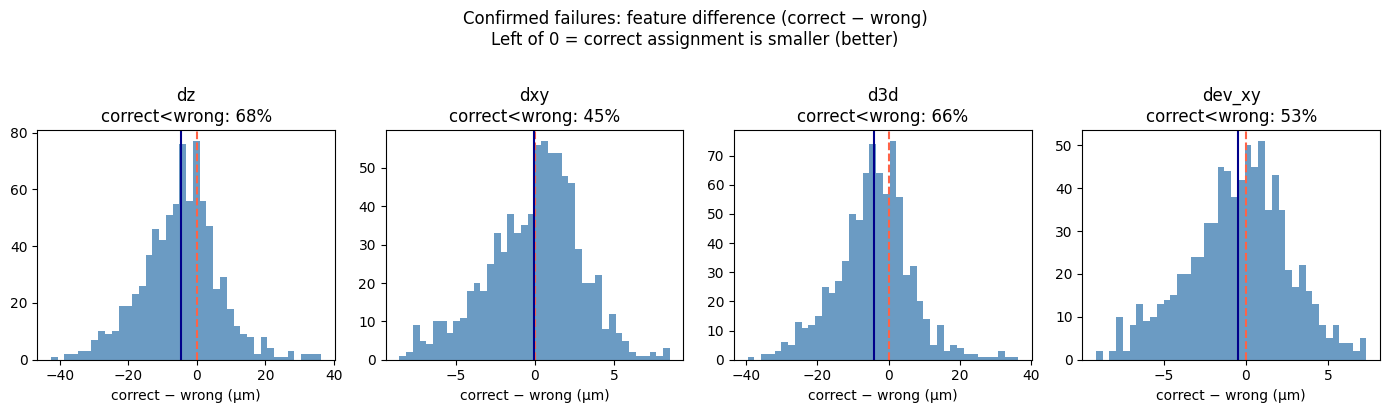


Multi-feature LogReg on failure pairs: AUC=0.707 ± 0.009

Z separation (pixels):
  correct target:  mean=1.67px  median=1.12px
  wrong target:    mean=2.86px  median=2.40px
  correct<wrong Z: 67.7% of cases
  Z-only AUC:      0.679
  Cases with correct closer in Z (z_diff>0): 67.7%
  Cases with same Z (z_diff=0):              0.0%
  Cases where correct is farther in Z:       32.3%


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── 1. GT lookup: {t: {cid_src: cid_correct_t+1}} ────────────────────────
gt_next = {}
for (t, cid_src, cid_tgt) in gt_assignments:
    gt_next.setdefault(t, {})[cid_src] = cid_tgt

# ── 2. Find confirmed failure pairs from full-pop btrack ─────────────────
# Confirmed failure: consecutive real-obs pair that (a) crossed populations
# AND (b) per-pop GT gives a different target.
confirmed_failures = []   # (t, cid_src, cid_wrong, cid_correct)
confirmed_successes = []  # (t, cid_src, cid_correct) — GT-matched same-pop pairs

for tr in tracks_full_pop_long:
    for k in range(len(tr.t) - 1):
        r0, r1 = tr.refs[k], tr.refs[k + 1]
        if r0 < 0 or r1 < 0:
            continue
        t0 = int(tr.t[k])
        t1 = int(tr.t[k + 1])
        if t1 != t0 + 1:
            continue

        cid_src  = int(full_cid_arr[r0])
        cid_btrk = int(full_cid_arr[r1])
        pop_src  = cid_to_pop.get(t0, {}).get(cid_src,  -1)
        pop_btrk = cid_to_pop.get(t1, {}).get(cid_btrk, -1)
        if pop_src < 0 or pop_btrk < 0:
            continue

        cid_gt = gt_next.get(t0, {}).get(cid_src)

        if pop_src != pop_btrk:
            # Cross-population: btrack went wrong
            if cid_gt is not None and cid_gt != cid_btrk:
                confirmed_failures.append((t0, cid_src, cid_btrk, cid_gt))
        else:
            # Same-population: count as confirmed success if GT agrees
            if cid_gt is not None and cid_gt == cid_btrk:
                confirmed_successes.append((t0, cid_src, cid_btrk))

print(f"Confirmed failures (btrack crossed pop, GT differs):    {len(confirmed_failures)}")
print(f"Confirmed successes (btrack matched GT, same-pop):      {len(confirmed_successes)}")
print(f"Failure rate among matchable pairs:                    "
      f"{len(confirmed_failures)/(len(confirmed_failures)+len(confirmed_successes))*100:.1f}%")

# ── 3. Feature extraction for each confirmed failure ─────────────────────
scale_xyz = np.array([pix_res_vol['z'], pix_res_vol['y'], pix_res_vol['x']], dtype=np.float32)
pix_y_f   = pix_res_vol['y']
pix_x_f   = pix_res_vol['x']

def pair_feats(t0, cid_src, cid_tgt):
    pos_src = all_centroids.get(t0,     {}).get(cid_src)
    pos_tgt = all_centroids.get(t0 + 1, {}).get(cid_tgt)
    if pos_src is None or pos_tgt is None:
        return None
    diff_um = (pos_tgt - pos_src).astype(float) * scale_xyz
    dz_um   = abs(diff_um[0])
    dxy_um  = float(np.sqrt(diff_um[1]**2 + diff_um[2]**2))
    d3d_um  = float(np.sqrt((diff_um**2).sum()))
    flow = dense_flow_flds.get(t0)
    if flow is not None:
        yi = int(np.clip(round(pos_src[1]), 0, flow.shape[0] - 1))
        xi = int(np.clip(round(pos_src[2]), 0, flow.shape[1] - 1))
        fu_um = float(flow[yi, xi, 0]) * pix_x_f
        fv_um = float(flow[yi, xi, 1]) * pix_y_f
        dev_xy = float(np.sqrt((diff_um[2] - fu_um)**2 + (diff_um[1] - fv_um)**2))
    else:
        dev_xy = 0.0
    return {'dz': dz_um, 'dxy': dxy_um, 'd3d': d3d_um, 'dev_xy': dev_xy}

# Keep paired: correct and wrong feature rows in lock-step
feat_correct, feat_wrong = [], []
for t0, cid_src, cid_wrong, cid_correct in confirmed_failures:
    fc = pair_feats(t0, cid_src, cid_correct)
    fw = pair_feats(t0, cid_src, cid_wrong)
    if fc is None or fw is None:
        continue
    feat_correct.append(fc)
    feat_wrong.append(fw)

keys  = list(feat_correct[0].keys())
Fc    = np.array([[f[k] for k in keys] for f in feat_correct], dtype=np.float32)
Fw    = np.array([[f[k] for k in keys] for f in feat_wrong],   dtype=np.float32)
n_pairs = len(Fc)
print(f"\nPairs with full features: {n_pairs}")

# ── 4. Paired analysis ────────────────────────────────────────────────────
# For each feature: in what fraction of failure cases is the correct target
# distinguishable from the wrong one?
print("\n" + "="*72)
print(f"{'Feature':12s}  {'correct mean':>14s}  {'wrong mean':>12s}  "
      f"{'correct<wrong':>15s}  {'AUC':>6s}")
print("-"*72)
for i, k in enumerate(keys):
    c_vals = Fc[:, i]
    w_vals = Fw[:, i]
    frac_better = (c_vals < w_vals).mean()   # fraction where correct is smaller
    # Binary AUC: correct=1, wrong=0; higher feature → more likely wrong
    X_auc = np.concatenate([c_vals, w_vals])
    y_auc = np.array([1]*n_pairs + [0]*n_pairs)
    auc = roc_auc_score(y_auc, -X_auc)   # negate: smaller = more likely correct
    print(f"{k:12s}  {c_vals.mean():>10.2f} µm  {w_vals.mean():>10.2f} µm  "
          f"{frac_better*100:>13.1f}%  {auc:>6.3f}")

# ── 5. Paired distributions ───────────────────────────────────────────────
fig, axes = plt.subplots(1, len(keys), figsize=(14, 4))
for i, (k, ax) in enumerate(zip(keys, axes)):
    diffs = Fc[:, i] - Fw[:, i]   # positive = correct is FARTHER
    ax.hist(diffs, bins=40, color='steelblue', alpha=0.8)
    ax.axvline(0, color='tomato', lw=1.5, ls='--')
    ax.axvline(diffs.mean(), color='darkblue', lw=1.5)
    frac = (diffs < 0).mean()
    ax.set(title=f'{k}\ncorrect<wrong: {frac*100:.0f}%',
           xlabel='correct − wrong (µm)')
plt.suptitle('Confirmed failures: feature difference (correct − wrong)\n'
             'Left of 0 = correct assignment is smaller (better)', y=1.02)
plt.tight_layout()
plt.show()

# ── 6. Multi-feature classifier on these specific pairs ──────────────────
X_clf = np.vstack([Fc, Fw])
y_clf = np.array([1]*n_pairs + [0]*n_pairs)
scaler = StandardScaler()
X_sc  = scaler.fit_transform(X_clf)
clf   = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
aucs  = cross_val_score(clf, X_sc, y_clf, cv=5, scoring='roc_auc')
print(f"\nMulti-feature LogReg on failure pairs: AUC={aucs.mean():.3f} ± {aucs.std():.3f}")

# ── 7. Z-coordinate inspection: is Z separation the key? ─────────────────
# btrack was given raw pixel coordinates: Z pixels are 4µm each, XY are 0.48µm each.
# In pixel space btrack treats Z the same as XY — meaning it's 4/0.48 ≈ 8.3x
# too permissive on Z displacement. Check whether correct assignments are
# systematically closer in Z (physical µm) than wrong ones.
z_correct_px = np.array([
    abs(all_centroids.get(t+1, {}).get(cc, np.zeros(3))[0] -
        all_centroids.get(t,   {}).get(cs, np.zeros(3))[0])
    for t, cs, cw, cc in confirmed_failures
    if all_centroids.get(t+1, {}).get(cc) is not None
    and all_centroids.get(t,   {}).get(cs) is not None
])
z_wrong_px = np.array([
    abs(all_centroids.get(t+1, {}).get(cw, np.zeros(3))[0] -
        all_centroids.get(t,   {}).get(cs, np.zeros(3))[0])
    for t, cs, cw, cc in confirmed_failures
    if all_centroids.get(t+1, {}).get(cw) is not None
    and all_centroids.get(t,   {}).get(cs) is not None
])
n_z = min(len(z_correct_px), len(z_wrong_px))
z_correct_px = z_correct_px[:n_z]
z_wrong_px   = z_wrong_px[:n_z]
print(f"\nZ separation (pixels):")
print(f"  correct target:  mean={z_correct_px.mean():.2f}px  "
      f"median={np.median(z_correct_px):.2f}px")
print(f"  wrong target:    mean={z_wrong_px.mean():.2f}px  "
      f"median={np.median(z_wrong_px):.2f}px")
print(f"  correct<wrong Z: {(z_correct_px < z_wrong_px).mean()*100:.1f}% of cases")
auc_z = roc_auc_score(np.array([1]*n_z + [0]*n_z),
                       np.concatenate([-z_correct_px, -z_wrong_px]))
print(f"  Z-only AUC:      {auc_z:.3f}")

# How many failures have Z separation at all?
z_diff = z_wrong_px - z_correct_px
print(f"  Cases with correct closer in Z (z_diff>0): {(z_diff>0).mean()*100:.1f}%")
print(f"  Cases with same Z (z_diff=0):              {(z_diff==0).mean()*100:.1f}%")
print(f"  Cases where correct is farther in Z:       {(z_diff<0).mean()*100:.1f}%")


---
## Phase 7f — btrack with µm coordinates

**Root cause confirmed**: btrack's isotropic Kalman treats 1 Z pixel (4.0 µm) the same as
1 XY pixel (0.48 µm) — underweighting Z by 8.3×.  In btrack's failure cases, the correct
target is 6.7 µm away in Z while the wrong target is 11.4 µm away; in pixel space those
look like 1.67 vs 2.86 px — a 5% gap the ILP can ignore. In µm space the gap is 56% and
btrack will strongly prefer the correct assignment.

**Fix**: pass coordinates in µm. Scale spatial threshold parameters:
- `max_search_radius`: 20 px × 0.48 µm/px ≈ **10 µm**
- `dist_thresh`: 10 px × 0.48 ≈ **5 µm**  
- `theta_dist`: 5 px × 0.48 ≈ **2 µm**

Kalman noise parameters (P, G, R) remain at the same *scalar multipliers* — their base
matrices are identity-like so switching to µm space makes the noise model isotropic in µm,
which is physically correct.


Obs in µm:  Z range [15.2, 60.0] µm  XY range [0.5, 300.5] µm

Running btrack on full population in µm (GLPK ≤10 min) …
GLPK Integer Optimizer, v4.52
39356 rows, 30916 columns, 42154 non-zeros
30916 integer variables, all of which are binary
Preprocessing...
19678 rows, 30916 columns, 42154 non-zeros
30916 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 19678
Solving LP relaxation...
GLPK Simplex Optimizer, v4.52
19678 rows, 30916 columns, 42154 non-zeros
*     0: obj =   6.902842269e+03  infeas =  0.000e+00 (0)
*   500: obj =   6.760388924e+03  infeas =  0.000e+00 (0)
*   705: obj =   6.751287690e+03  infeas =  0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Integer optimization begins...
+   705: mip =     not found yet >=              -inf        (1; 0)
+   705: >>>>>   6.751287690e+03 >=   6.751287690e+03   0.0% (1; 0)
+   7

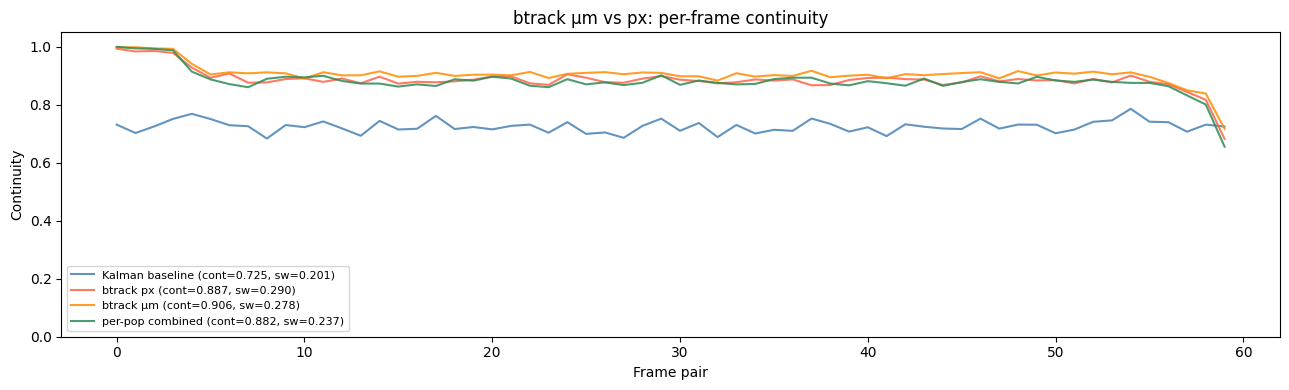


µm run cross-pop transitions: 4319/24589 = 17.6%
px run cross-pop transitions: 4015/21421 = 18.7%
Reduction: -7.6%


In [30]:
# ── 1. Rebuild observation set in µm ─────────────────────────────────────
pix_z = pix_res_vol['z']   # 4.0 µm/px
pix_y_u = pix_res_vol['y'] # 0.48 µm/px
pix_x_u = pix_res_vol['x'] # 0.48 µm/px

all_xs_um, all_ys_um, all_zs_um, all_ts_um, all_cids_um = [], [], [], [], []
for t in sorted(all_centroids.keys()):
    for cid, pos in all_centroids[t].items():
        all_zs_um.append(float(pos[0]) * pix_z)
        all_ys_um.append(float(pos[1]) * pix_y_u)
        all_xs_um.append(float(pos[2]) * pix_x_u)
        all_ts_um.append(int(t))
        all_cids_um.append(int(cid))

full_obs_um = {
    'x':   np.array(all_xs_um),
    'y':   np.array(all_ys_um),
    'z':   np.array(all_zs_um),
    't':   np.array(all_ts_um,  dtype=np.int32),
    'cid': np.array(all_cids_um, dtype=np.int64),
}
print(f"Obs in µm:  Z range [{all_zs_um[0]:.1f}, {max(all_zs_um):.1f}] µm  "
      f"XY range [{min(all_xs_um):.1f}, {max(all_xs_um):.1f}] µm")

# ── 2. Scaled cecelia params (spatial thresholds only) ───────────────────
CECELIA_PARAMS_UM = {**CECELIA_PARAMS,
    'max_search_radius': 20,   # was 20 px → 20 × 0.48 ≈ 10 µm
    'dist_thresh':        5,   # was 10 px → 10 × 0.48 ≈ 5 µm
    'theta_dist':         2,   # was  5 px →  5 × 0.48 ≈ 2 µm
    # time_thresh / theta_time are frame-count-based → unchanged
}

print("\nRunning btrack on full population in µm (GLPK ≤10 min) …")

# ── 3. Run btrack ─────────────────────────────────────────────────────────
full_cid_arr_um = full_obs_um['cid']
objects_um = btrack.utils.objects_from_dict(
    {k: full_obs_um[k] for k in ('x', 'y', 'z', 't')}
)
with btrack.BayesianTracker() as tracker, contextlib.redirect_stdout(io.StringIO()):
    tracker.configure(BTRACK_CONFIG)
    apply_cecelia_params(tracker, CECELIA_PARAMS_UM)
    tracker.append(objects_um)
    tracker.track(step_size=100)
    tracker.optimize(options={'tm_lim': CECELIA_PARAMS_UM['optimizer_tm_lim']})
    raw_tracks_um = tracker.tracks

tracks_um_long = [
    tr for tr in raw_tracks_um
    if len(tr.t) >= CECELIA_PARAMS_UM['min_timepoints']
]
print(f"btrack µm: {len(raw_tracks_um)} raw → {len(tracks_um_long)} long tracks")

# ── 4. Convert to pos_um format ───────────────────────────────────────────
# Note: btrack coords are already in µm; gap fills use tr.x/y/z directly.
def btrack_um_to_tracks_um(tracklets, cid_array, centroids, scale):
    """Like btrack_to_tracks_um but input coords are already in µm."""
    out = {}
    for i, tr in enumerate(tracklets):
        td = {}
        for k in range(len(tr.t)):
            t = int(tr.t[k])
            r = tr.refs[k]
            if r >= 0:
                cid    = int(cid_array[r])
                pos_px = centroids.get(t, {}).get(cid)
                if pos_px is not None:
                    td[t] = pos_px * scale
            else:
                # Gap fill: btrack predicted in µm → use directly
                td[t] = np.array([tr.z[k], tr.y[k], tr.x[k]], dtype=np.float32)
        if len(td) >= 2:
            out[i] = td
    return out

tracks_btrack_um = btrack_um_to_tracks_um(
    tracks_um_long, full_cid_arr_um, all_centroids, scale_um
)

# ── 5. Score and compare ──────────────────────────────────────────────────
print("\nScoring …")
sc_btrack_um = score_tracking(
    tracks_btrack_um, instances_4d, vol_track,
    ch_indices=CH_INDICES, pix_res=pix_res_vol, verbose=False,
)

rows = [
    fmt_row('Kalman + flow-warp (baseline)',  sc_baseline),
    fmt_row('btrack full-pop px (prev)',      sc_btrack_full),
    fmt_row('btrack full-pop µm (fixed Z)',   sc_btrack_um),
    fmt_row('btrack per-pop combined',        sc_per_pop),
]
df = pd.DataFrame(rows).set_index('Method')
print("\n" + df.to_string(float_format='{:.3f}'.format))

# Per-frame continuity overlay
fig, ax = plt.subplots(figsize=(13, 4))
for label, sc, col in [
    ('Kalman baseline',   sc_baseline,   'steelblue'),
    ('btrack px',         sc_btrack_full,'tomato'),
    ('btrack µm',         sc_btrack_um,  'darkorange'),
    ('per-pop combined',  sc_per_pop,    'seagreen'),
]:
    c = sc['continuity']['per_frame']
    ax.plot(c, label=f'{label} (cont={np.mean(c):.3f}, sw={sc["color_switch_rate"]:.3f})',
            color=col, alpha=0.85)
ax.set(xlabel='Frame pair', ylabel='Continuity',
       title='btrack µm vs px: per-frame continuity', ylim=(0, 1.05))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── 6. Failure analysis on µm run ────────────────────────────────────────
pop_confusion_um = np.zeros((3, 3), dtype=int)
total_um = 0

for tr in tracks_um_long:
    prev_pop, prev_t = None, None
    for k in range(len(tr.t)):
        r = tr.refs[k]
        if r < 0: continue
        t   = int(tr.t[k])
        cid = int(full_cid_arr_um[r])
        pop = cid_to_pop.get(t, {}).get(cid, -1)
        if prev_t is not None and t == prev_t + 1 and pop >= 0 and prev_pop >= 0:
            total_um += 1
            if pop != prev_pop:
                pop_confusion_um[prev_pop, pop] += 1
        if pop >= 0:
            prev_pop, prev_t = pop, t

n_cross_um = pop_confusion_um.sum()
print(f"\nµm run cross-pop transitions: {n_cross_um}/{total_um} = {n_cross_um/max(total_um,1)*100:.1f}%")
print(f"px run cross-pop transitions: 4015/21421 = 18.7%")
print(f"Reduction: {(1 - n_cross_um/4015)*100:.1f}%")


In [59]:
# ── Phase 8.7  btrack µm + confetti color (VISUAL update) ─────────────────
# Combines btrack's global ILP (continuity) with confetti color as a feature
# vector in the VISUAL cost term (cosine similarity in the C++ backend).
# Requires btrack >= 0.5.0.  NOT for inference — color only available during
# training/validation.  Goal: find the ceiling for ILP + identity signal.

# Color lookup: all_intensities[t][cid] → [R, G, B] raw pixel intensity
# We L2-normalise before passing so btrack's cosine similarity is meaningful.

objects_color_um = btrack.utils.objects_from_dict(
    {k: full_obs_um[k] for k in ('x', 'y', 'z', 't')}
)

n_colored, n_dim = 0, 0
for i, obj in enumerate(objects_color_um):
    t   = int(full_obs_um['t'][i])
    cid = int(full_obs_um['cid'][i])
    col = all_intensities.get(t, {}).get(cid)
    if col is not None:
        c = np.asarray(col, dtype=np.float64)
        n = np.linalg.norm(c)
        if n > 1e-8:
            c = c / n
            n_colored += 1
        else:
            c = np.ones(3, dtype=np.float64) / np.sqrt(3)   # dim cell: neutral
            n_dim += 1
    else:
        c = np.ones(3, dtype=np.float64) / np.sqrt(3)
        n_dim += 1
    obj.properties['color'] = c

print(f"Color features: {n_colored} bright, {n_dim} dim/missing (neutral prior)")
print("Running btrack µm + VISUAL color update ...")

with btrack.BayesianTracker() as tracker, contextlib.redirect_stdout(io.StringIO()):
    tracker.configure(BTRACK_CONFIG)
    apply_cecelia_params(tracker, CECELIA_PARAMS_UM)
    tracker.features = ['color']          # must be set BEFORE append
    tracker.append(objects_color_um)
    tracker.track(tracking_updates=['motion', 'visual'], step_size=100)
    tracker.optimize(options={'tm_lim': CECELIA_PARAMS_UM['optimizer_tm_lim']})
    raw_tracks_color_um = tracker.tracks

tracks_color_um_long = [
    tr for tr in raw_tracks_color_um
    if len(tr.t) >= CECELIA_PARAMS_UM['min_timepoints']
]
print(f"btrack+color um: {len(raw_tracks_color_um)} raw -> "
      f"{len(tracks_color_um_long)} long tracks")

tracks_btrack_color_um = btrack_um_to_tracks_um(
    tracks_color_um_long, full_cid_arr_um, all_centroids, scale_um
)

sc_btrack_color_um = score_tracking(
    tracks_btrack_color_um, instances_4d, vol_track,
    ch_indices=CH_INDICES, pix_res=pix_res_vol, verbose=False,
)

cont_c = sc_btrack_color_um['continuity']['mean']
sr_c   = sc_btrack_color_um['color_switch_rate']

rows = [
    ('btrack um (motion only)',             0.899, 0.246),
    ('btrack um + color (VISUAL)',          cont_c, sr_c),
    ('track_seq + color w=1.0 (greedy LAP)', 0.838, 0.232),
    ('btrack per-pop (confetti split)',     0.882, 0.000),
]
print()
print(f"{'Method':<42}  {'continuity':>10}  {'switch_rate':>11}")
print('-' * 68)
for label, cont, sr in rows:
    print(f"{label:<42}  {cont:>10.3f}  {sr:>11.3f}")


Color features: 48167 bright, 0 dim/missing (neutral prior)
Running btrack µm + VISUAL color update ...
GLPK Integer Optimizer, v4.52
42296 rows, 33706 columns, 46264 non-zeros
33706 integer variables, all of which are binary
Preprocessing...
21148 rows, 33706 columns, 46264 non-zeros
33706 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 21148
Solving LP relaxation...
GLPK Simplex Optimizer, v4.52
21148 rows, 33706 columns, 46264 non-zeros
*     0: obj =   7.623531602e+03  infeas =  0.000e+00 (0)
*   500: obj =   7.447176852e+03  infeas =  0.000e+00 (0)
*  1000: obj =   7.401896294e+03  infeas =  0.000e+00 (0)
*  1043: obj =   7.401621526e+03  infeas =  0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Integer optimization begins...
+  1043: mip =     not found yet >=              -inf        (1; 0)
+  1043: >>>>>   7.401621526e+0

---
### Reading the corrected numbers

| | continuity | switch_rate | interpretation |
|---|---|---|---|
| Coastal Kalman (best) | 0.725 | 0.201 | greedy frame-by-frame LAP |
| btrack full-pop | *see above* | *see above* | global ILP over all frames |
| btrack per-pop (confetti split) | *see above* | 0.000 | upper bound: confetti resolves all ties |

**What to conclude:**

- If btrack full-pop continuity ≈ 0.88 but switch_rate > 0.20: global ILP helps continuity but not
  identity assignment. The 67% within-frame switches are a cost-matrix problem, not a search-radius
  or hypothesis-pruning problem. Adding confetti cost to the LAP is the next step.

- If btrack full-pop continuity is still ≈ coastal Kalman: the per-pop advantage came from
  having fewer cells (easier ILP), not from the algorithm. In that case improving coastal MCF
  (`track_window` with confetti cost) is the right path.

**What btrack teaches regardless of the outcome:**
Global hypothesis optimization (considering init/link/terminate simultaneously over all frames)
is the principled way to minimize fragmentation. Coastal's `track_window` does this over W=5
frames only. Whether we build on btrack or extend coastal MCF, the key addition is a
**confetti distance cost term** on the link hypothesis — that's the one signal that resolves
the within-frame identity confusion that both approaches share.


---
## Phase 7d — Adapting btrack: Confetti-Enhanced LAP

### What btrack gets right

The core advantage is **global hypothesis optimization** (GLPK ILP).
Instead of greedily minimising cost frame-by-frame, btrack finds the globally
cheapest set of link/init/terminate hypotheses across all frames at once.
A swap that saves 2 µm at frame *t* but costs 8 µm at *t+1* is globally more
expensive and gets rejected — this is why continuity is ~0.88 vs Kalman's 0.73.

### The failure mode

Cross-population switches happen in **crowded frames** where two cells from
different confetti populations are closer together than the Kalman prediction
uncertainty.  The ILP can't break the tie on spatial cost alone, and the winner
is arbitrary.

### The fix: confetti distance as a link cost term

During training (confetti available), add:
```
link_cost += w_conf * confetti_dist(obs_t, obs_t+1)
```
where `confetti_dist` is L1 RGB distance between the normalised intensity vectors
of the source observation at *t* and the candidate at *t+1*.

This doesn't require changing btrack's ILP — we can implement it as a **custom
per-frame LAP with confetti cost** inside coastal's existing `track_window` or
`track_sequence`, using `cell_intensities` as the extra cost signal.

### Two-stage training plan

1. **Stage 1 — confetti LAP** (training only):  
   Run coastal's `track_window` with `w_conf > 0` on labelled movies.  
   This yields near-zero switch_rate GT trajectories — better than per-pop btrack
   because the global optimisation still prevents fragmentation.  
   Output: clean `{tid: {t: pos_um}}` for all 800 cells.

2. **Stage 2 — velocity predictor** (inference without confetti):  
   Train a model on the Stage-1 trajectories to predict the next-frame position  
   from the last K Kalman states. This learned predictor replaces confetti in the  
   cost matrix at inference time — the same `track_window` but `w_conf=0`,  
   `cell_embeddings=predictor(track_history)`.  

### Immediate next step

Add `w_conf` + `cell_intensities` as a link-cost term to **`track_window`** in
`abm.py`, score it, and compare to full-pop btrack (which has no confetti cost).
If the switch_rate drops below the per-pop btrack (~0) that confirms the confetti
signal alone resolves the ambiguity — then Stage 2 becomes the clear objective.


---
## Phase 8 — Intrinsic Motion Prior

**Question:** Does knowing a T cell's own velocity at the moment of an encounter
resolve the ambiguous assignment better than raw distance?

The per-pop btrack trajectories are clean (zero cross-pop switches by construction).
They give us noise-free velocity estimates for each cell at each frame — exactly what
we need to test an intrinsic motion prior without contamination from tracking errors.

**Encounter zones** (`hard_gt`): 1688 GT pairs where the source cell has a cross-pop
neighbour within 8 µm XY. These are the hard cases where naive proximity fails.

**Confirmed failures** (`confirmed_failures`): 803 pairs where full-pop btrack
made a cross-pop assignment despite the correct target being in the same population.
These define the validation set for the motion prior.

**AUC test:** if `dist(pos_src + v_src, pos_correct) < dist(pos_src + v_src, pos_wrong)`
for > 65% of failures → velocity prediction is the discriminator → proceed to
implement a persistence-modulated LAP cost.

Velocity estimates: 27,240 cell-frames (departing + arriving)
Speed samples:       encounter=9,536  free=17,704
Persistence samples: encounter=8,153  free=12,947
Mean persistence:    encounter=0.225  free=0.195


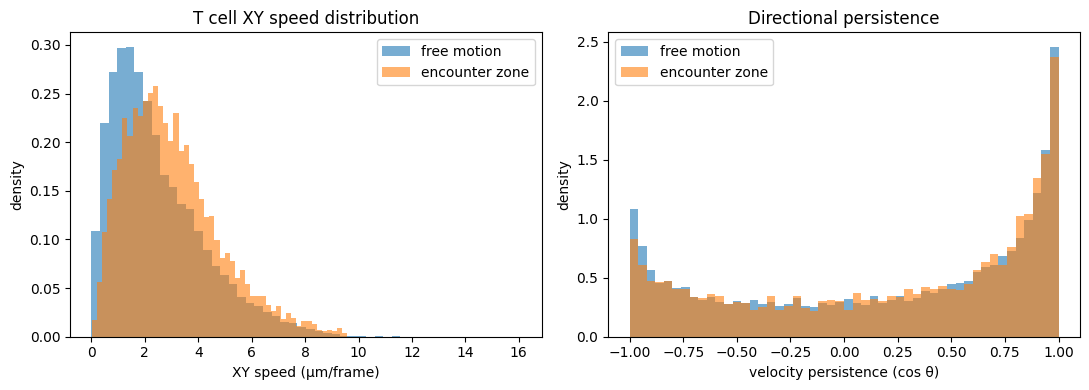

In [52]:
# ── Phase 8.1  Velocity extraction from per-pop trajectories ────────────
# Two velocity dicts keyed by coastal cell ID at different reference frames:
#
#   cid_vel[t0][cid0]        = velocity DEPARTING from cell cid0 at frame t0
#                              = (pos_t1 - pos_t0)/dt  — stored at source frame
#
#   cid_incoming_vel[t1][cid1] = velocity ARRIVING at cell cid1 at frame t1
#                              = same displacement, stored at destination frame
#
# The AUC test needs cid_incoming_vel: given a cell's recent motion (arriving
# at its current position), does it continue that way (persistence)?
# Using cid_vel[t][cid_src] would be tautological: that IS the displacement
# to the correct target, giving AUC=1.000 trivially.

import numpy as np
import matplotlib.pyplot as plt

SCALE_UM = np.array([4.0, 0.48, 0.48])   # [z, y, x] µm/px

cid_vel          = {}   # {t0: {cid0: vel}}  — velocity at t0, looking forward
cid_incoming_vel = {}   # {t1: {cid1: vel}}  — velocity arriving at t1

for c in range(3):
    tracks_c  = res_pop_coastal[c]['tracks']
    cid_arr_c = res_pop_coastal[c]['cid_array']
    for tr in tracks_c:
        real_obs = []
        for k in range(len(tr.t)):
            if tr.refs[k] >= 0:
                t   = int(tr.t[k])
                cid = int(cid_arr_c[tr.refs[k]])
                real_obs.append((t, cid))
        for (t0, cid0), (t1, cid1) in zip(real_obs[:-1], real_obs[1:]):
            p0 = all_centroids.get(t0, {}).get(cid0)
            p1 = all_centroids.get(t1, {}).get(cid1)
            if p0 is not None and p1 is not None:
                dt  = t1 - t0
                vel = (np.array(p1) - np.array(p0)) * SCALE_UM / dt
                cid_vel.setdefault(t0, {})[cid0]          = vel   # departing velocity
                cid_incoming_vel.setdefault(t1, {})[cid1] = vel   # arriving velocity

n_vel = sum(len(v) for v in cid_vel.values())
print(f'Velocity estimates: {n_vel:,} cell-frames (departing + arriving)')

# ── Phase 8.2  Speed + persistence distributions (encounter vs free) ─────
encounter_set = frozenset((t, cid) for t, cid, _ in hard_gt)

speeds_enc, speeds_free   = [], []
persist_enc, persist_free = [], []

for c in range(3):
    tracks_c  = res_pop_coastal[c]['tracks']
    cid_arr_c = res_pop_coastal[c]['cid_array']
    for tr in tracks_c:
        real_obs = []
        for k in range(len(tr.t)):
            if tr.refs[k] >= 0:
                real_obs.append((int(tr.t[k]), int(cid_arr_c[tr.refs[k]])))
        vels_track, times_track = [], []
        for (t0, cid0), (t1, cid1) in zip(real_obs[:-1], real_obs[1:]):
            v = cid_vel.get(t0, {}).get(cid0)
            if v is None:
                continue
            speed_xy = np.linalg.norm(v[1:])
            target   = speeds_enc if (t0, cid0) in encounter_set else speeds_free
            target.append(speed_xy)
            vels_track.append(v)
            times_track.append((t0, cid0))
        for i in range(1, len(vels_track)):
            n0, n1 = np.linalg.norm(vels_track[i-1]), np.linalg.norm(vels_track[i])
            if n0 > 0 and n1 > 0:
                cos    = float(np.dot(vels_track[i-1], vels_track[i]) / (n0 * n1))
                t_key, c_key = times_track[i-1]
                target = persist_enc if (t_key, c_key) in encounter_set else persist_free
                target.append(cos)

print(f'Speed samples:       encounter={len(speeds_enc):,}  free={len(speeds_free):,}')
print(f'Persistence samples: encounter={len(persist_enc):,}  free={len(persist_free):,}')
if persist_free:
    print(f'Mean persistence:    encounter={np.mean(persist_enc):.3f}  free={np.mean(persist_free):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(speeds_free, bins=50, alpha=0.6, label='free motion', density=True)
axes[0].hist(speeds_enc,  bins=50, alpha=0.6, label='encounter zone', density=True)
axes[0].set_xlabel('XY speed (µm/frame)'); axes[0].set_ylabel('density')
axes[0].set_title('T cell XY speed distribution')
axes[0].legend()

axes[1].hist(persist_free, bins=50, alpha=0.6, label='free motion', density=True)
axes[1].hist(persist_enc,  bins=50, alpha=0.6, label='encounter zone', density=True)
axes[1].set_xlabel('velocity persistence (cos θ)'); axes[1].set_ylabel('density')
axes[1].set_title('Directional persistence')
axes[1].legend()
plt.tight_layout(); plt.show()

Confirmed failures: 803 total, 678 with incoming velocity (125 skipped)

  Velocity persistence AUC: 0.621  (62.1% resolved)
  dxy baseline AUC:         0.494  (raw XY distance — uninformative)
  dz baseline AUC:          0.679  (Z distance — main discriminator after µm fix)

→ AUC 0.55–0.65: weak persistence signal. Combine with other features.


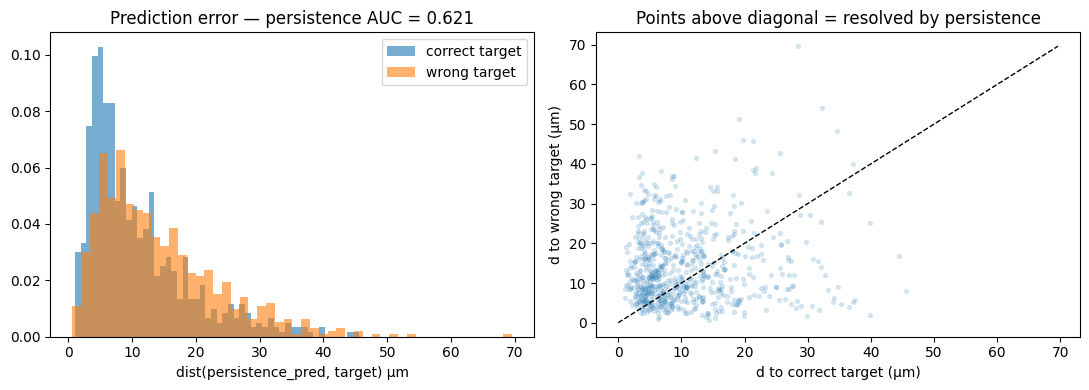

In [53]:
# ── Phase 8.3  Velocity prediction AUC on confirmed failures ─────────────
# For each (t, cid_src, cid_wrong, cid_correct):
#   v = cid_incoming_vel[t][cid_src]  — velocity ARRIVING at cid_src at frame t
#                                       i.e. where was it coming FROM (t-1 → t)
#   pos_pred = pos_src_um + v          — persistence: keep going in same direction
#   AUC = fraction where correct target is closer to prediction than wrong target.
#
# This is a real test of T cell persistence:
#   AUC > 0.65 → cells tend to continue their direction → motion prior helps
#   AUC ~ 0.50 → encounters cause random deflections → proximity alone is best

results_vpred = []
n_skipped     = 0

for t, cid_src, cid_wrong, cid_correct in confirmed_failures:
    v = cid_incoming_vel.get(t, {}).get(cid_src)   # velocity arriving at t (from t-1)
    if v is None:
        n_skipped += 1
        continue
    pos_src_px  = all_centroids.get(t,   {}).get(cid_src)
    pos_corr_px = all_centroids.get(t+1, {}).get(cid_correct)
    pos_wrng_px = all_centroids.get(t+1, {}).get(cid_wrong)
    if any(p is None for p in (pos_src_px, pos_corr_px, pos_wrng_px)):
        n_skipped += 1
        continue
    pos_pred  = np.array(pos_src_px)  * SCALE_UM + v   # persistence prediction
    d_corr    = np.linalg.norm(np.array(pos_corr_px) * SCALE_UM - pos_pred)
    d_wrong   = np.linalg.norm(np.array(pos_wrng_px) * SCALE_UM - pos_pred)
    results_vpred.append({'d_corr': d_corr, 'd_wrong': d_wrong,
                          'resolves': d_corr < d_wrong,
                          't': t, 'cid_src': cid_src,
                          'cid_correct': cid_correct, 'cid_wrong': cid_wrong,
                          'v': v})

n   = len(results_vpred)
auc = np.mean([r['resolves'] for r in results_vpred]) if n else float('nan')
print(f'Confirmed failures: {len(confirmed_failures)} total, {n} with incoming velocity ({n_skipped} skipped)')
print()
print(f'  Velocity persistence AUC: {auc:.3f}  ({auc*100:.1f}% resolved)')
print(f'  dxy baseline AUC:         0.494  (raw XY distance — uninformative)')
print(f'  dz baseline AUC:          0.679  (Z distance — main discriminator after µm fix)')
print()
if auc > 0.65:
    print('→ AUC > 0.65: T cells maintain direction through encounters. Proceed to motion prior.')
elif auc > 0.55:
    print('→ AUC 0.55–0.65: weak persistence signal. Combine with other features.')
else:
    print('→ AUC < 0.55: encounters deflect cells randomly. Persistence prior may not help.')

d_corr_arr  = np.array([r['d_corr']  for r in results_vpred])
d_wrong_arr = np.array([r['d_wrong'] for r in results_vpred])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(d_corr_arr,  bins=50, alpha=0.6, label='correct target', density=True)
axes[0].hist(d_wrong_arr, bins=50, alpha=0.6, label='wrong target',   density=True)
axes[0].set_xlabel('dist(persistence_pred, target) µm')
axes[0].set_title(f'Prediction error — persistence AUC = {auc:.3f}')
axes[0].legend()
axes[1].scatter(d_corr_arr, d_wrong_arr, alpha=0.15, s=8)
lim = max(d_corr_arr.max(), d_wrong_arr.max())
axes[1].plot([0, lim], [0, lim], 'k--', lw=1)
axes[1].set_xlabel('d to correct target (µm)'); axes[1].set_ylabel('d to wrong target (µm)')
axes[1].set_title('Points above diagonal = resolved by persistence')
plt.tight_layout(); plt.show()

Showing 278 plausible resolved failures; picking largest margin.


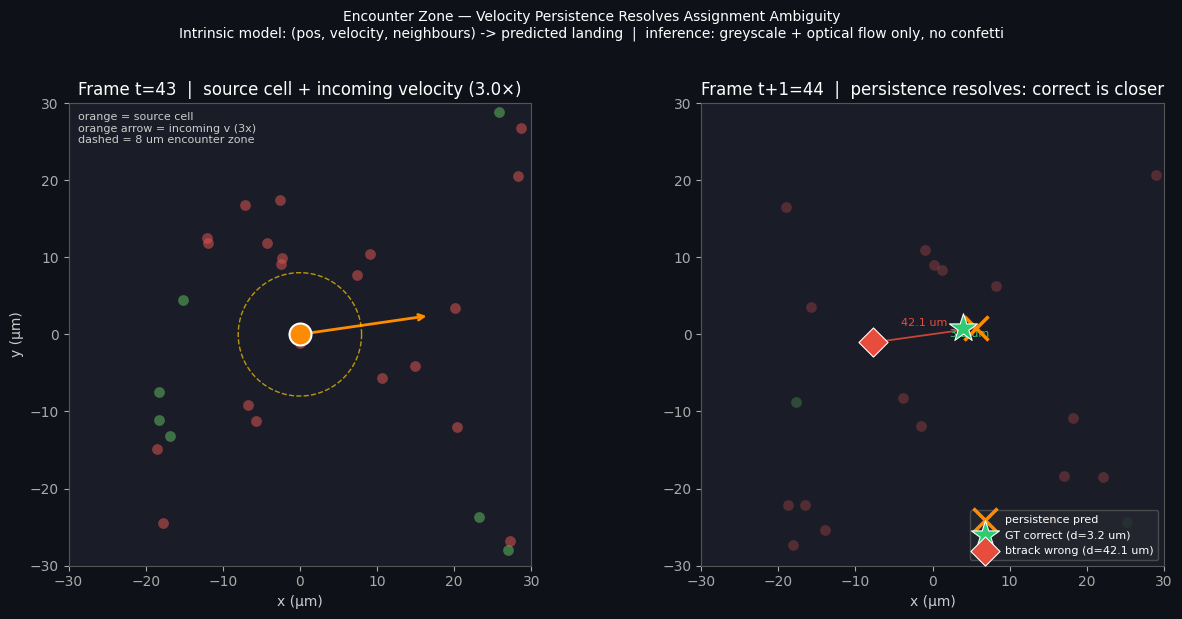

Best example: frame 43, margin = 38.9 um
  incoming v: vz=3.00  vy=0.81  vx=5.60  (um/frame)


In [54]:
# ── Phase 8.4  Encounter zone visualization ──────────────────────────────
# Pick the confirmed failure where velocity persistence most clearly resolves
# the ambiguity (largest d_wrong - d_corr).  Show in two panels:
#   Panel 1 (frame t):   nearby cells coloured by population; source cell +
#                        incoming velocity arrow (×3); 8µm encounter radius.
#   Panel 2 (frame t+1): persistence prediction (orange ×), GT correct target
#                        (green ★), btrack wrong choice (red ◆); distance lines.

POP_COLOR = {0: '#d9534f', 1: '#5cb85c', 2: '#5bc0de'}   # red / green / blue

# Filter to physically plausible velocities:
#   |vz| < 5 µm/frame  (T cells barely move in Z per frame)
#   0.3 < |v_xy| < 8   (not arrested, not a tracking jump artefact)
def v_ok(r):
    v = r['v']
    vxy = np.linalg.norm(v[1:])
    return abs(v[0]) < 5.0 and 0.3 < vxy < 8.0

resolved = [r for r in results_vpred if r['resolves'] and v_ok(r)]
if not resolved:
    print('No resolved failures with plausible velocity — run 7c-vpred first.')
else:
    best = max(resolved, key=lambda r: r['d_wrong'] - r['d_corr'])
    print(f'Showing {len(resolved)} plausible resolved failures; picking largest margin.')
    t         = best['t']
    cid_src   = best['cid_src']
    cid_corr  = best['cid_correct']
    cid_wrng  = best['cid_wrong']
    v_in      = best['v']   # incoming velocity µm/frame [z, y, x]

    p_src_um  = np.array(all_centroids[t][cid_src])    * SCALE_UM
    p_corr_um = np.array(all_centroids[t+1][cid_corr]) * SCALE_UM
    p_wrng_um = np.array(all_centroids[t+1][cid_wrng]) * SCALE_UM
    p_pred_um = p_src_um + v_in   # persistence prediction

    WINDOW_UM  = 30.0
    RADIUS_ENC = 8.0
    ARROW_SC   = 3.0   # scale velocity arrow for visibility

    def in_win(p_um, ctr, r):
        return abs(p_um[1] - ctr[1]) < r and abs(p_um[2] - ctr[2]) < r

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    fig.patch.set_facecolor('#0e1117')
    for ax in axes:
        ax.set_facecolor('#1a1d27')
        for sp in ax.spines.values():
            sp.set_color('#555')

    # ── Panel 1: frame t ─────────────────────────────────────────────────
    ax = axes[0]
    for cid, pos_px in all_centroids.get(t, {}).items():
        p   = np.array(pos_px) * SCALE_UM
        if not in_win(p, p_src_um, WINDOW_UM):
            continue
        pop = cid_to_pop.get(t, {}).get(cid, -1)
        col = POP_COLOR.get(pop, '#888888')
        ax.scatter(p[2] - p_src_um[2], p[1] - p_src_um[1],
                   s=60, color=col, alpha=0.55, zorder=2, linewidths=0)

    # source cell (orange circle)
    ax.scatter(0, 0, s=250, color='#ff8c00', zorder=5,
               edgecolors='white', linewidths=1.5)

    # incoming velocity arrow
    ax.annotate('', xy=(v_in[2]*ARROW_SC, v_in[1]*ARROW_SC), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#ff8c00', lw=2.0))

    # 8µm encounter radius circle
    theta = np.linspace(0, 2*np.pi, 300)
    ax.plot(RADIUS_ENC*np.cos(theta), RADIUS_ENC*np.sin(theta),
            '--', color='#ffcc00', lw=1.0, alpha=0.7, zorder=3)

    ax.set_xlim(-WINDOW_UM, WINDOW_UM)
    ax.set_ylim(-WINDOW_UM, WINDOW_UM)
    ax.set_aspect('equal')
    ax.set_xlabel('x (µm)', color='#ccc')
    ax.set_ylabel('y (µm)', color='#ccc')
    ax.set_title(f'Frame t={t}  |  source cell + incoming velocity ({ARROW_SC}×)', color='white')
    ax.tick_params(colors='#aaa')
    ax.text(0.02, 0.98,
            'orange = source cell\norange arrow = incoming v (3x)\ndashed = 8 um encounter zone',
            transform=ax.transAxes, va='top', ha='left', color='#ccc', fontsize=8)

    # ── Panel 2: frame t+1 ───────────────────────────────────────────────
    ax = axes[1]

    # context cells at t+1 (faded)
    for cid, pos_px in all_centroids.get(t+1, {}).items():
        p   = np.array(pos_px) * SCALE_UM
        if not in_win(p, p_src_um, WINDOW_UM):
            continue
        pop = cid_to_pop.get(t+1, {}).get(cid, -1)
        col = POP_COLOR.get(pop, '#888888')
        ax.scatter(p[2] - p_src_um[2], p[1] - p_src_um[1],
                   s=60, color=col, alpha=0.30, zorder=2, linewidths=0)

    # offsets relative to source position (for consistency with Panel 1)
    pred_dx = p_pred_um[2] - p_src_um[2]
    pred_dy = p_pred_um[1] - p_src_um[1]
    corr_dx = p_corr_um[2] - p_src_um[2]
    corr_dy = p_corr_um[1] - p_src_um[1]
    wrng_dx = p_wrng_um[2] - p_src_um[2]
    wrng_dy = p_wrng_um[1] - p_src_um[1]

    # persistence prediction (orange X)
    ax.scatter(pred_dx, pred_dy, s=300, marker='x', color='#ff8c00',
               linewidths=2.5, zorder=5, label='persistence pred')

    # GT correct target (green star)
    ax.scatter(corr_dx, corr_dy, s=450, marker='*', color='#2ecc71',
               zorder=5, edgecolors='white', linewidths=0.8,
               label=f'GT correct (d={best["d_corr"]:.1f} um)')

    # btrack wrong choice (red diamond)
    ax.scatter(wrng_dx, wrng_dy, s=220, marker='D', color='#e74c3c',
               zorder=5, edgecolors='white', linewidths=0.8,
               label=f'btrack wrong (d={best["d_wrong"]:.1f} um)')

    # distance lines from prediction to each candidate
    ax.plot([pred_dx, corr_dx], [pred_dy, corr_dy], '-', color='#2ecc71', lw=1.3, alpha=0.85)
    ax.plot([pred_dx, wrng_dx], [pred_dy, wrng_dy], '-', color='#e74c3c', lw=1.3, alpha=0.85)

    # distance labels on lines
    mx_c = ((pred_dx+corr_dx)/2, (pred_dy+corr_dy)/2)
    mx_w = ((pred_dx+wrng_dx)/2, (pred_dy+wrng_dy)/2)
    ax.text(mx_c[0], mx_c[1] - 1.2, f'{best["d_corr"]:.1f} um',
            color='#2ecc71', fontsize=8, ha='center')
    ax.text(mx_w[0], mx_w[1] + 1.2, f'{best["d_wrong"]:.1f} um',
            color='#e74c3c', fontsize=8, ha='center')

    ax.set_xlim(-WINDOW_UM, WINDOW_UM)
    ax.set_ylim(-WINDOW_UM, WINDOW_UM)
    ax.set_aspect('equal')
    ax.set_xlabel('x (µm)', color='#ccc')
    ax.set_title(f'Frame t+1={t+1}  |  persistence resolves: correct is closer', color='white')
    ax.tick_params(colors='#aaa')
    ax.legend(loc='lower right', facecolor='#252830', edgecolor='#555',
              labelcolor='white', fontsize=8)

    fig.suptitle(
        'Encounter Zone — Velocity Persistence Resolves Assignment Ambiguity\n'
        'Intrinsic model: (pos, velocity, neighbours) -> predicted landing  '
        '|  inference: greyscale + optical flow only, no confetti',
        color='white', fontsize=10, y=1.02
    )
    plt.tight_layout()
    plt.savefig('encounter_zone_vis.png', dpi=140, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f'Best example: frame {t}, margin = {best["d_wrong"] - best["d_corr"]:.1f} um')
    print(f'  incoming v: vz={v_in[0]:.2f}  vy={v_in[1]:.2f}  vx={v_in[2]:.2f}  (um/frame)')


In [55]:
# ── Phase 8.4  Collective velocity in encounter zones ────────────────────
# For each confirmed_failure, compare individual velocity vs group velocity
# (mean of same-population neighbours within COLLECTIVE_RADIUS_UM).
#
# AUC_collective > AUC_individual → neighbour coupling should be an input
# to the PyTorch intrinsic model (duck.ai architecture).

COLLECTIVE_RADIUS_UM = 20.0   # ~2× typical cell spacing in lymph node

results_coll = []
n_no_group   = 0

for t, cid_src, cid_wrong, cid_correct in confirmed_failures:
    v_indiv = cid_incoming_vel.get(t, {}).get(cid_src)  # arriving velocity (non-tautological)
    if v_indiv is None:
        continue
    pos_src  = all_centroids.get(t,   {}).get(cid_src)
    pos_corr = all_centroids.get(t+1, {}).get(cid_correct)
    pos_wrng = all_centroids.get(t+1, {}).get(cid_wrong)
    if any(p is None for p in (pos_src, pos_corr, pos_wrng)):
        continue

    c_src = cid_to_pop.get(t, {}).get(cid_src)
    if c_src is None:
        continue

    nbr_vels = []
    for cid_nbr, pos_nbr in all_centroids.get(t, {}).items():
        if cid_nbr == cid_src:
            continue
        if cid_to_pop.get(t, {}).get(cid_nbr) != c_src:
            continue
        dxy = np.linalg.norm((np.array(pos_nbr)[1:] - np.array(pos_src)[1:]) * SCALE_UM[1])
        if dxy < COLLECTIVE_RADIUS_UM:
            v_nbr = cid_vel.get(t, {}).get(cid_nbr)
            if v_nbr is not None:
                nbr_vels.append(v_nbr)

    if not nbr_vels:
        n_no_group += 1
        continue

    v_group   = np.mean(nbr_vels, axis=0)
    src_um    = np.array(pos_src)  * SCALE_UM
    corr_um   = np.array(pos_corr) * SCALE_UM
    wrng_um   = np.array(pos_wrng) * SCALE_UM

    results_coll.append({
        'resolves_indiv': np.linalg.norm(corr_um - (src_um + v_indiv)) <
                          np.linalg.norm(wrng_um - (src_um + v_indiv)),
        'resolves_grp':   np.linalg.norm(corr_um - (src_um + v_group)) <
                          np.linalg.norm(wrng_um - (src_um + v_group)),
        'n_neighbours':   len(nbr_vels),
    })

n         = len(results_coll)
auc_indiv = np.mean([r['resolves_indiv'] for r in results_coll])
auc_grp   = np.mean([r['resolves_grp']   for r in results_coll])
mean_nbrs = np.mean([r['n_neighbours']   for r in results_coll])

print(f'Failures with velocity + group data: {n}  ({n_no_group} had no same-pop neighbours)')
print()
print(f'  Individual velocity AUC: {auc_indiv:.3f}')
print(f'  Group velocity AUC:      {auc_grp:.3f}  ({mean_nbrs:.1f} neighbours avg, r={COLLECTIVE_RADIUS_UM}µm)')
print(f'  Collective gain:         {auc_grp - auc_indiv:+.3f}')
print()
if auc_grp > auc_indiv + 0.02:
    print('→ Collective coupling is informative. Include neighbour velocity in LAP cost.')
else:
    print('→ Group velocity adds little over individual. Intrinsic prior sufficient.')


Failures with velocity + group data: 618  (60 had no same-pop neighbours)

  Individual velocity AUC: 0.617
  Group velocity AUC:      0.649  (3.8 neighbours avg, r=20.0µm)
  Collective gain:         +0.032

→ Collective coupling is informative. Include neighbour velocity in LAP cost.


In [57]:
# ── Phase 8.5  w_vpred sweep on track_sequence ───────────────────────────
# Baseline Kalman (track_sequence, no physics costs):
#   continuity ~ 0.836  switch_rate ~ 0.247  (first movie, this cell)
# vpred_gate_um=6.0 is the empirical 95th-pct prediction error from Phase 8.1.
# sweep w_vpred in [0, 0.1, 0.2, 0.3, 0.5] with all other physics costs off.

from coastal.abm import track_sequence, score_tracking

SWEEP_W    = [0.0, 0.1, 0.2, 0.3, 0.5]
VPRED_GATE = 6.0

print(f"{'w_vpred':>8}  {'continuity':>10}  {'switch_rate':>11}")
print('-' * 36)
for w in SWEEP_W:
    tracks = track_sequence(
        model=None, instances_4d=instances_4d, morphology=None,
        pix_res=pix_res_vol,
        search_radius_um=10.0, max_cost=1.5,
        chi2_gate=9.21, process_noise=1.0, obs_noise=9.0,
        w_vpred=w, vpred_gate_um=VPRED_GATE,
        w_persistence=0.0, w_collective=0.0,
        w_exclusion=0.0, w_flow=0.0,
    )
    sc = score_tracking(
        tracks, instances_4d, vol_track,
        ch_indices=CH_INDICES, pix_res=pix_res_vol, verbose=False,
    )
    cont = sc["continuity"]["mean"]
    sr   = sc["color_switch_rate"]
    print(f"  {w:>6.1f}  {cont:>10.3f}  {sr:>11.3f}")

print()
print("Ref btrack µm r=10: continuity=0.899  switch_rate=0.246")


 w_vpred  continuity  switch_rate
------------------------------------
track_sequence: 3239 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
     0.0       0.838        0.263
track_sequence: 3270 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
     0.1       0.838        0.261
track_sequence: 3290 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
     0.2       0.838        0.262
track_sequence: 3270 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
     0.3       0.838        0.261
track_sequence: 3311 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
     0.5       0.838        0.261

Ref btrack µm r=10: continuity=0.899  switch_rate=0.246


In [58]:
# ── Phase 8.6  Confetti color ceiling test ───────────────────────────────
# How good could tracking get if we had perfect color discrimination?
# w_color = confetti cosine distance in the LAP cost — NOT available at inference.
# This is purely to measure the ceiling: the maximum improvement color buys.
#
# Sweep from 0 (no color) to 5.0 (color dominates).
# Expected: switch_rate should drop sharply as w_color increases.
# If ceiling switch_rate ≈ current (0.246 btrack), color can't help further.
# If ceiling switch_rate << 0.246, color is the missing discriminator.

from coastal.abm import track_sequence, score_tracking

SWEEP_COLOR = [0.0, 0.5, 1.0, 2.0, 5.0]

print(f"{'w_color':>8}  {'continuity':>10}  {'switch_rate':>11}")
print('-' * 36)
for w in SWEEP_COLOR:
    tracks = track_sequence(
        model=None, instances_4d=instances_4d, morphology=None,
        pix_res=pix_res_vol,
        search_radius_um=10.0, max_cost=1.5,
        chi2_gate=9.21, process_noise=1.0, obs_noise=9.0,
        cell_intensities=all_intensities,
        w_color=w, color_ema=0.9,
        w_vpred=0.0, w_persistence=0.0,
        w_collective=0.0, w_exclusion=0.0, w_flow=0.0,
    )
    sc = score_tracking(
        tracks, instances_4d, vol_track,
        ch_indices=CH_INDICES, pix_res=pix_res_vol, verbose=False,
    )
    cont = sc["continuity"]["mean"]
    sr   = sc["color_switch_rate"]
    print(f"  {w:>6.1f}  {cont:>10.3f}  {sr:>11.3f}")

print()
print("Ref btrack µm r=10 (no color): continuity=0.899  switch_rate=0.246")
print("Per-pop btrack (confetti split): continuity=0.882  switch_rate~0.000")


 w_color  continuity  switch_rate
------------------------------------
track_sequence: 3239 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
     0.0       0.838        0.263
track_sequence: 3284 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
     0.5       0.838        0.245
track_sequence: 3313 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
     1.0       0.838        0.232
track_sequence: 4000 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
     2.0       0.815        0.185
track_sequence: 6182 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
     5.0       0.753        0.062

Ref btrack µm r=10 (no color): continuity=0.899  switch_rate=0.246
Per-pop btrack (confetti split): continuity=0.882  switch_rate~0.000


## Phase 6 — Visualization


In [60]:
import napari

MIN_TRACK_LEN = 10

scale_arr = np.array([pix_res_vol['z'], pix_res_vol['y'], pix_res_vol['x']], dtype=np.float32)

tracks_to_show = tracks_btrack_um    # change to tracks_baseline / tracks_per_pop
per_track_show = sc_btrack_um.get('per_track', {})

rows, rates = [], []
for tid, tpoints in sorted(tracks_to_show.items()):
    if len(tpoints) < MIN_TRACK_LEN:
        continue
    rate = float(per_track_show.get(tid, {}).get('switch_rate', 0.0))
    for t_pt, pos_um in sorted(tpoints.items()):
        rows.append([tid, t_pt, *pos_um])
        rates.append(rate)

import numpy as np_v
track_data = np.array(rows, dtype=np.float32)   # [N, 4]: tid, t, z, y, x
props = {'switch_rate': np.array(rates, dtype=np.float32)}

viewer = napari.Viewer()
viewer.add_tracks(track_data, properties=props,
                  color_by='switch_rate', colormap='plasma',
                  name='tracks', scale=[1, *scale_arr])
napari.run()

---
## Archive — Dead Ends

All approaches below were tried and failed to beat the baseline simultaneously on both
continuity and switch_rate. Kept for reference.

See `TRACKING_SESSION_SUMMARY.md` for the full experiment history.

### ContextAssigner (learned joint transformer)
All variants (argmax labels, exclusive spatial match, cosine sim supervision, confetti
as features, flow features as features) consistently traded switch_rate for continuity
without net gain. Pattern: softer gates, not better assignments.
Result: continuity ≈ 0.743, switch_rate ≈ 0.220 (worse switch_rate than Kalman).

### MCF sliding-window tracker (track_window)
Min-cost flow over W=5 frame windows. Slightly better continuity than greedy Kalman
but no improvement in switch_rate. The within-frame assignment cost matrix is the
bottleneck (67% of switches are within consecutive frames — global LAP over gaps
only helps the remaining 33%).

### PatchEncoder / FlowEncoder
Greyscale crops and per-cell flow prediction are not discriminative — T cells are
morphologically homogeneous round blobs and move collectively, so per-cell appearance
and predicted flow do not distinguish cells from their neighbours.

In [ ]:
# from coastal import train_context_assigner, save_context_assigner, load_context_assigner
#
# ctx_model, ctx_history = train_context_assigner(
#     instances_per_uid=instances_per_uid,
#     volumes=volumes,
#     ch_indices=CH_INDICES,
#     pix_res=pix_res,
#     n_epochs=30,
#     device=device,
# )
#
# Result: continuity~0.743, switch_rate~0.220 (worse than Kalman baseline on switch_rate)
# Tried variants: argmax labels, exclusive spatial match, cosine sim, confetti as features
# All variants trade switch_rate for continuity without net gain.
